# **Google Playstore Data**
**Complete Exploratory Data Analysis**

### About Dataset

>- **`Description`**\
> The Data Set was downloaded from Kaggle, from the following [link](https://www.kaggle.com/datasets/lava18/google-play-store-apps/)

- `Context`
While many public datasets (on Kaggle and the like) provide Apple App Store data, there are not many counterpart datasets available for Google Play Store apps anywhere on the web. On digging deeper, I found out that iTunes App Store page deploys a nicely indexed appendix-like structure to allow for simple and easy web scraping. On the other hand, Google Play Store uses sophisticated modern-day techniques (like dynamic page load) using JQuery making scraping more challenging.

- `Content`
Each app (row) has values for catergory, rating, size, and more.

- `Acknowledgements`
This information is scraped from the Google Play Store. This app information would not be available without it.

- `Inspiration`
The Play Store apps data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for developers to work on and capture the Android market!

### 1. **Importing Libraries**

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hide all warnings runtime
import warnings
warnings.filterwarnings('ignore')

# Enable inline plotting so charts appear directly inside Jupyter Notebook
%matplotlib inline

### 2. **Data Loading, Exploration and Cleaning**
 - Load the csv file with the pandas
 
 - creating the dataframe and understanding the data present in the dataset using pandas
 
 - Dealing with the missing data, outliers and the incorrect records

In [94]:
# Load the dataset into a pandas DataFrame from the CSV file

df = pd.read_csv('googleplaystore_new.csv')

In [95]:
# Display the first 5 rows of the dataset to get a quick look at the data

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


> **Note**: Some the output of notebook does not present the complete output, therefore we can increase the limit of columns view and row view by using these commands: 

In [96]:
# Set pandas option to display all rows in the DataFrame output
pd.set_option('display.max_rows', None)

# Set pandas option to display all columns in the DataFrame output
pd.set_option('display.max_columns', None)

In [97]:
# Display the list of all column names in the dataset

df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

- Let's have a look on the shape of the dataset

In [98]:
# Display the shape of the dataset (number of rows and columns)

df.shape

(10841, 13)

Not enough, let's have a look on the columns and their data types using detailed info function

In [99]:
# Display a concise summary of the dataset, including column names, data types, and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10841 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10839 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.1+ MB


In [100]:
#Checking for duplicate rows

df.duplicated().sum()

np.int64(483)

### **Observations**
---
1. There are 10841 rows and 13 columns in the dataset
2. The columns are of different data types
3. The columns in the datasets are:
   - `'App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'`
4. A total of 483 duplicate rows were found in the dataset.
   - At this stage, duplicates are only checked to assess data quality and will be reviewed or handled after initial cleaning and validation.
5. There are some missing values in the dataset which we will read in details and deal later on in the notebook.
6. There are some columns which are of object data type but they should be of numeric data type, we will convert them later on in the notebook.
   - `'Size', 'Installs', 'Price'` 

In [101]:
df.describe()

,Rating,Reviews
count,9367.000000,1.084100e+04
mean,4.191513,4.441119e+05
std,0.515735,2.927629e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.094000e+03
75%,4.500000,5.476800e+04
max,5.000000,7.815831e+07


**Observation:**

- We have only 2 columns as numeric data type, rest all are object data type (according to python), but we can see that `'Size', 'Installs', 'Price'` are also numeric, we must convert them to numeric data type.
---

- Let's clean the `Size` column first

In [102]:
# Check for null values

df['Size'].isnull().sum()

np.int64(0)

- No null values, we are good to go.

In [103]:
# Check unique values

df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

-  There are several uniques values in the `Size` column, we have to first make the unit into one common unit from M and K to bytes, and then remove the `M` and `K` from the values and convert them into numeric data type.

In [104]:
# # Count how many values in the 'Size' column contain the character 'M'

df['Size'].loc[df['Size'].str.contains('M')].value_counts().sum()

np.int64(8830)

In [105]:
# Count how many values in the 'Size' column contain the character 'k'

df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [106]:
# Count how many rows in the 'Size' column contain the text 'Varies with device'

df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts().sum()

np.int64(1695)

In [107]:
# Count of all non-missing values in the 'Size' column

df['Size'].value_counts().sum()

np.int64(10841)

In [108]:
# Summing the counts of entries in the 'Size' column that contain 'M', 'k', or 'Varies with device'

8830 + 316 + 1695

10841

- We have `8830` values in `M` units
- We have `316` values in `k` units
- We have `1695` value in `Varies with device` 

> Let's convert the `M` and `K` units into bytes and then remove the `M` and `K` from the values and convert them into numeric data type.

In [109]:
# ============================================================
# Convert the 'Size' column to numeric (in bytes)
# ============================================================
# - Values ending with 'k' are multiplied by 1024 (to convert KB → Bytes)
# - Values ending with 'M' are multiplied by 1024 * 1024 (to convert MB → Bytes)
# - Entries with 'Varies with device' are replaced with NaN
# ============================================================

def convert_size(size):
    """
    Convert size values (e.g., '12k', '2.5M', 'Varies with device') into numeric byte values.
    
    Parameters:
        size (str or numeric): The size value to convert.

    Returns:
        float: Size in bytes (numeric) or NaN if not applicable.
    """
    
    if isinstance(size, str):   # only convert if value is a string (avoid errors on NaN/numeric)
        size = size.strip()     # remove extra spaces just in case
        if 'k' in size:
            return float(size.replace('k', '')) * 1024              # KB -> Bytes
        elif 'M' in size:
            return float(size.replace('M', '')) * 1024 * 1024       # MB -> Bytes
        elif 'Varies with device' in size:
            return np.nan                                           # Missing / variable size
        
    # Return unchanged if already numeric or other type
    return size

# Apply conversion to the 'Size' column
df['Size'] = df['Size'].apply(convert_size)


In [110]:
# Rename the column name 'Size' to 'Size_in_bytes'

df.rename(columns = {'Size': 'Size_in_Bytes'}, inplace = True)

In [111]:
# Create a new column 'Size_in_MB' by converting size from bytes to megabytes

df['Size_in_MB'] = df['Size_in_Bytes'] / (1024 * 1024)

- Now we have converted every value into bytes and removed the `M` and `K` from the values and converted them into numeric data type.
- 'Varies with device' was a string value, therefore we intentionally converted them into null values, which we can fill later on according to our needs.

---
- Let's have a look on the `Installs` column

In [112]:
# Check for null values

df['Installs'].isnull().sum()

np.int64(0)

In [113]:
# Check the unique values in size column

df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [114]:
# Let's have a values counts

df['Installs'].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             908
5,000,000+         752
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Name: count, dtype: int64

In [115]:
# Find how many values in the 'Installs' column contain the '+' symbol

df['Installs'].loc[df['Installs'].str.contains('\+')].value_counts().sum()

np.int64(10840)

In [116]:
# Total values in Installs column

df['Installs'].value_counts().sum()

np.int64(10841)

### Observations

- The `Installs` column contains a total of 10,841 values, and there are no null values in it.

- Most of the values include a `+` sign (e.g., `'1,000+'`, `'10,000+'`), but one value — `'0'` — does not have a plus sign.

- The `+`sign and commas (`,`) make the column non-numeric, even though it represents numbers.

- To make this column suitable for numerical analysis or modeling, we should remove the `+` and `,` characters, then convert the column to a numeric data type (e.g., `int` or `float`).

In [117]:
# ==============================================
# Clean and Convert 'Installs' Column to Numeric
# ==============================================

# Remove '+' symbols from the 'Installs' values (e.g., '1,000,000+' --> '1,000,000')
df['Installs'] = df['Installs'].apply(lambda x: x.replace('+', '') if '+' in str(x) else x)

# Remove commas to prepare for numeric conversion (e.g., '1,000,000' --> '1000000')
df['Installs'] = df['Installs'].apply(lambda x: x.replace(',', '') if ',' in str(x) else x)

# Convert the cleaned 'Installs' values to integers (since installs are whole-number counts)
df['Installs'] = df['Installs'].astype(int)


- Let's verify if the dtypes has been changes and the `+` and `,` sign has been removed

In [118]:
# Check the head of the dataframe

df.head()

,App,Category,Rating,Reviews,Size_in_Bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19922944.0,10000,Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14680064.0,500000,Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,9122611.2,5000000,Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,26214400.0,50000000,Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2936012.8,100000,Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up,2.8


In [119]:
# Check the data type of the 'Installs' column

df['Installs'].dtype

dtype('int64')

- We can generate a new columns based on the installation values, which will be helpful in our analysis

In [120]:
# Returns the highest value in the 'Installs' column

df['Installs'].max() 

np.int64(1000000000)

In [121]:
# ===============================
# Categorize 'Installs' into meaningful ranges
# ===============================

# Define the bin edges (range breakpoints) for 'Installs'
bins = [-1, 0, 10, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 1_000_000_000]

# Define corresponding category labels for each bin range
labels = ['No', 'Very Low', 'Low', 'Moderate', 'More than Moderate', 'High', 'Very High', 'Top Notch']

# Create a new column 'Installs_Category' based on these bins
df['Installs_Category'] = pd.cut(df['Installs'], bins=bins, labels=labels)


In [122]:
# Check the value counts of the new column

df['Installs_Category'].value_counts()

Installs_Category
Low                   2162
High                  2118
Very High             2004
More than Moderate    1648
Moderate              1531
Top Notch              828
Very Low               535
No                      15
Name: count, dtype: int64

- Let's have a look on the `Price` column

In [123]:
# Check for null values

df['Price'].isnull().sum()

np.int64(0)

In [124]:
# Check the unique values in the 'Price' column

df['Price'].unique()

array(['0', '$4.99 ', '$3.99 ', '$6.99 ', '$1.49 ', '$2.99 ', '$7.99 ',
       '$5.99 ', '$3.49 ', '$1.99 ', '$9.99 ', '$7.49 ', '$0.99 ',
       '$9.00 ', '$5.49 ', '$10.00 ', '$24.99 ', '$11.99 ', '$79.99 ',
       '$16.99 ', '$14.99 ', '$1.00 ', '$29.99 ', '$12.99 ', '$2.49 ',
       '$10.99 ', '$1.50 ', '$19.99 ', '$15.99 ', '$33.99 ', '$74.99 ',
       '$39.99 ', '$3.95 ', '$4.49 ', '$1.70 ', '$8.99 ', '$2.00 ',
       '$3.88 ', '$25.99 ', '$399.99 ', '$17.99 ', '$400.00 ', '$3.02 ',
       '$1.76 ', '$4.84 ', '$4.77 ', '$1.61 ', '$2.50 ', '$1.59 ',
       '$6.49 ', '$1.29 ', '$5.00 ', '$13.99 ', '$299.99 ', '$379.99 ',
       '$37.99 ', '$18.99 ', '$389.99 ', '$19.90 ', '$8.49 ', '$1.75 ',
       '$14.00 ', '$4.85 ', '$46.99 ', '$109.99 ', '$154.99 ', '$3.08 ',
       '$2.59 ', '$4.80 ', '$1.96 ', '$19.40 ', '$3.90 ', '$4.59 ',
       '$15.46 ', '$3.04 ', '$4.29 ', '$2.60 ', '$3.28 ', '$4.60 ',
       '$28.99 ', '$2.95 ', '$2.90 ', '$1.97 ', '$200.00 ', '$89.99 ',
       '$2.56 '

In [125]:
# Check how many times each unique price appears in the 'Price' column

df['Price'].value_counts()

Price
0           10041
$0.99         148
$2.99         129
$1.99          73
$4.99          72
$3.99          63
$1.49          46
$5.99          30
$2.49          26
$9.99          21
$6.99          13
$399.99        12
$14.99         11
$4.49           9
$29.99          7
$3.49           7
$7.99           7
$24.99          7
$5.49           6
$19.99          6
$6.49           5
$8.99           5
$12.99          5
$11.99          5
$10.00          3
$1.00           3
$16.99          3
$2.00           3
$17.99          2
$10.99          2
$9.00           2
$79.99          2
$7.49           2
$3.95           2
$33.99          2
$1.70           2
$13.99          2
$8.49           2
$39.99          2
$1.50           1
$25.99          1
$74.99          1
$15.99          1
$3.88           1
$1.76           1
$3.02           1
$400.00         1
$4.84           1
$2.50           1
$1.59           1
$1.61           1
$4.77           1
$5.00           1
$1.29           1
$379.99         1
$299

- We need to confirm if the values in the `Price` column are only with $ sign or not

In [126]:
# Count how many entries in the 'Price' column contain the dollar symbol ($)

df['Price'].loc[df['Price'].str.contains('\$')].value_counts().sum()

np.int64(800)

In [127]:
# Counts how many 'Price' values contain the digit "0" but do not include the "$" symbol

df['Price'].loc[(df['Price'].str.contains('0')) & (~df['Price'].str.contains('\$'))].value_counts().sum()

np.int64(10041)

- Now we can confirm that the only currency used is `$` in the `Price` column or 0 value, as `800+10041=10841 Total values`
- The only problem is $ sign let's remove it and convert the column into numeric data type.

In [128]:
# Remove the dollar sign ('$') from the 'Price' column 
# and convert it to a numeric data type (float) for analysis

df['Price'] = df['Price'].replace('\$','', regex=True).astype(float)

In [129]:
# Displays the data type of the 'Price' column

df['Price'].dtype


dtype('float64')

In [130]:
# Print the minimum, maximum, and average app prices

print(f'Min price is: {min(df['Price'])} $')
print(f'Max price is: {max(df['Price'])} $')
print(f'Average price is: {(df['Price'].mean())} $')

Min price is: 0.0 $
Max price is: 400.0 $
Average price is: 1.0272733142699015 $


### **2.1. Descriptive Statistics**

In [131]:
df.describe()

,Rating,Reviews,Size_in_Bytes,Installs,Price,Size_in_MB
count,9367.000000,1.084100e+04,9.146000e+03,1.084100e+04,10841.000000,9146.000000
mean,4.191513,4.441119e+05,2.255921e+07,1.546291e+07,1.027273,21.514141
std,0.515735,2.927629e+06,2.368595e+07,8.502557e+07,15.948971,22.588679
min,1.000000,0.000000e+00,8.704000e+03,0.000000e+00,0.000000,0.008301
25%,4.000000,3.800000e+01,5.138022e+06,1.000000e+03,0.000000,4.900000
50%,4.300000,2.094000e+03,1.363149e+07,1.000000e+05,0.000000,13.000000
75%,4.500000,5.476800e+04,3.145728e+07,5.000000e+06,0.000000,30.000000
max,5.000000,7.815831e+07,1.048576e+08,1.000000e+09,400.000000,100.000000


### Observations:
---
- We now have 6 numeric columns: `Rating`, `Reviews`, `Size_in_Bytes`, `Installs`, `Price`, and `Size_in_MB`.

- We can observe their descriptive statistics and make several observations based on our hypotheses.

- The `Rating` column ranges from 1 to 5, with an average of 4.19 and a low standard deviation (0.51) — indicating that most apps are rated between 4.0–4.5, showing consistent and good user satisfaction.

- The `Reviews` column ranges from 0 to 78M, but the mean (~4.4L) is much higher than the median (~2K) — suggesting a right-skewed distribution, where a few apps receive the majority of reviews.
On average, people give this number of reviews to apps, but this average isn’t meaningful across all apps since different categories have very different popularity levels.

- The `Installs` column ranges from 0 to 1B, also showing a highly right-skewed pattern — only a few apps dominate the total installs, while most apps have comparatively low downloads.

- The `Size_in_MB` column shows that most apps are small to medium-sized, with an average of ~21 MB, and a range from 0.008 MB to 100 MB.

- The `Price` column has a mean of ~$1.03, but 75% of apps are free (median = 0) — only a small fraction are premium apps, with a few outliers priced as high as $400.

- Overall, the Google Play Store primarily consists of free, small-sized, and well-rated apps, while a few highly popular or expensive apps skew the averages.

> And the most important thing is to classify as app based on the correlation matrix and then observe the descriptive statistics of the app category and number of installs, reviews, ratings, etc.

> But even before that we have to think about the missing values in the dataset.

---

### **2.2. Dealing with the missing values**
Dealing with the missing values is one of the most important part of the data wrangling process, we must deal with the missing values in order to get the correct insights from the data.

- Let's have a look on the missing values in the dataset

In [132]:
# Displays the total number of missing (null) values in each column

df.isnull().sum()


App                     0
Category                1
Rating               1474
Reviews                 0
Size_in_Bytes        1695
Installs                0
Type                    1
Price                   0
Content Rating          0
Genres                  1
Last Updated            0
Current Ver             8
Android Ver             2
Size_in_MB           1695
Installs_Category       0
dtype: int64

In [133]:
# Display the total number of missing (null) values in each column, sorted in descending order

df.isnull().sum().sort_values(ascending=False)


Size_in_Bytes        1695
Size_in_MB           1695
Rating               1474
Current Ver             8
Android Ver             2
Type                    1
Category                1
Genres                  1
Installs                0
App                     0
Reviews                 0
Last Updated            0
Content Rating          0
Price                   0
Installs_Category       0
dtype: int64

In [134]:
# Displays the total count of missing (null) values across the entire DataFrame

df.isnull().sum().sum()


np.int64(4877)

In [135]:
# Display the percentage of missing (null) values in each column, sorted in descending order

(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)


Size_in_Bytes        15.635089
Size_in_MB           15.635089
Rating               13.596532
Current Ver           0.073794
Android Ver           0.018448
Type                  0.009224
Category              0.009224
Genres                0.009224
Installs              0.000000
App                   0.000000
Reviews               0.000000
Last Updated          0.000000
Content Rating        0.000000
Price                 0.000000
Installs_Category     0.000000
dtype: float64

- Let's plot the missing values in the dataset

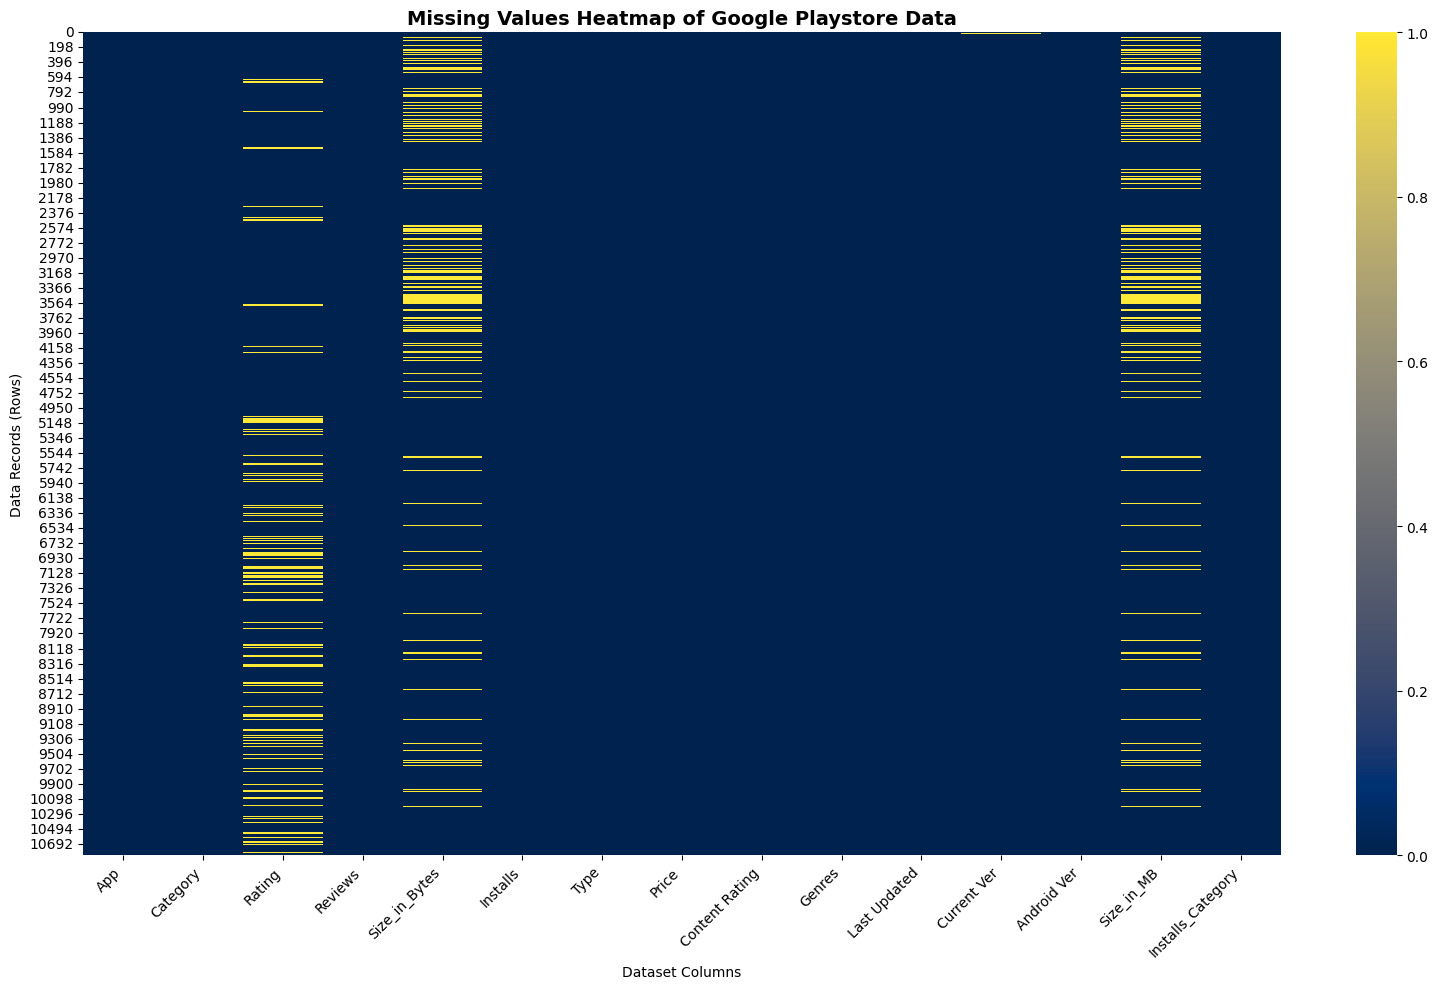

In [136]:
# Set the figure size
plt.figure(figsize = (16,10))

# Plot the missing values in the DataFrame
sns.heatmap(df.isnull(), cbar=True, cmap='cividis') 

# Add a descriptive title and axis labels
plt.title('Missing Values Heatmap of Google Playstore Data', fontsize=14, fontweight='bold')
plt.xlabel('Dataset Columns')
plt.ylabel('Data Records (Rows)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent label or title overlap
plt.tight_layout()

# Display the plot
plt.show()

- There is another way, let's plot the missing values by percentage

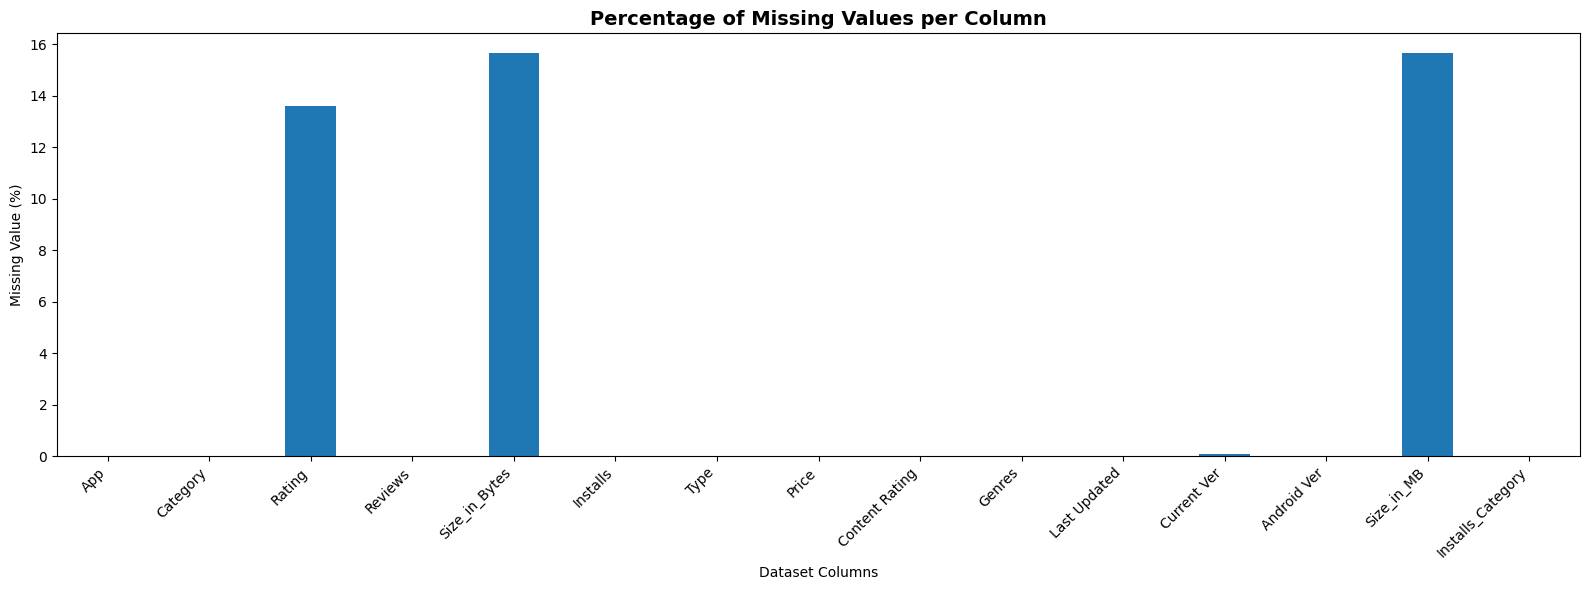

In [137]:
# Set the figure size
plt.figure(figsize=(16,6))

# Calculate and Plot the missing percentages as a bar chart
missing_percentage = df.isnull().sum()/len(df) * 100
missing_percentage.plot(kind='bar')

# Add title and axis labels for clarity
plt.title('Percentage of Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('Dataset Columns')
plt.ylabel('Missing Value (%)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent overlap of labels/titles
plt.tight_layout()

# Display the plot
plt.show()

- We will visualize the columns—excluding `Rating`, `Size_in_Bytes` and `Size_in_MB`—that have under 1% missing data.

- Since the missing proportion is minimal, these columns will be dropped from the dataset.

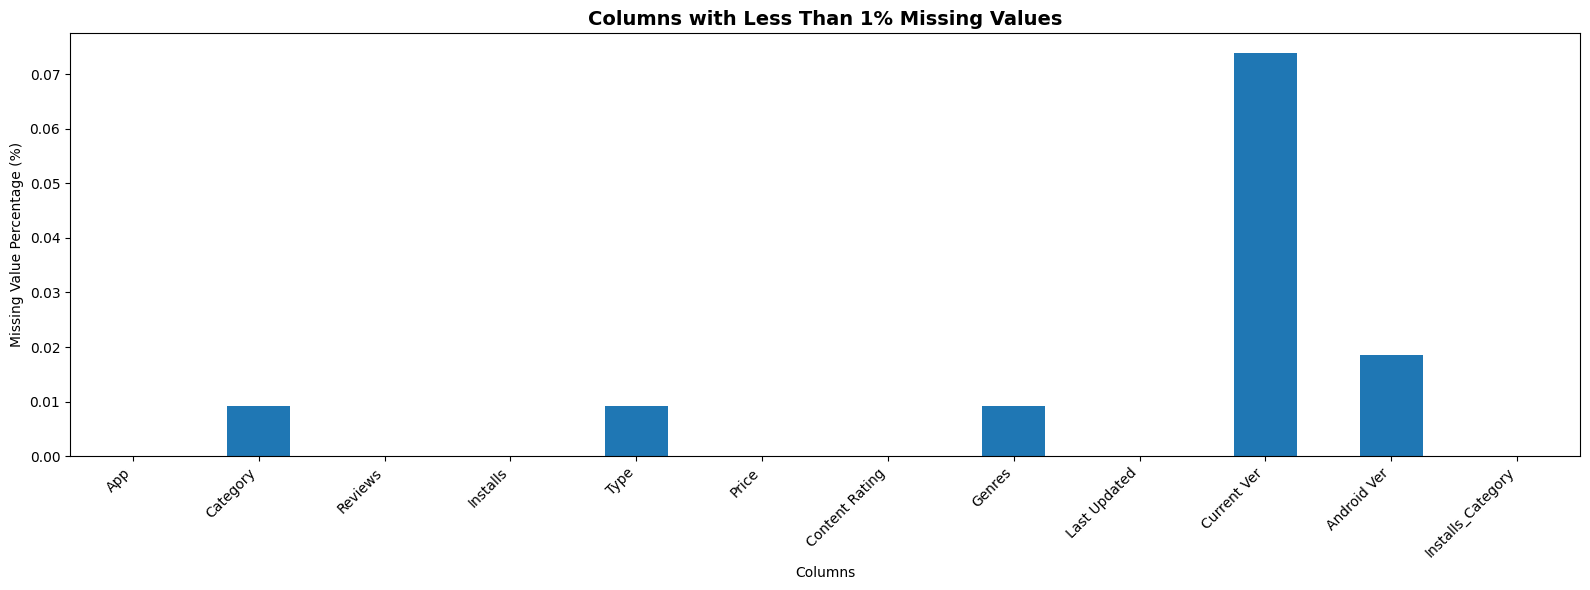

In [138]:
# Set the figure size
plt.figure(figsize=(16,6))

# Plot columns where missing percentage is less than 1%
missing_percentage[missing_percentage < 1].plot(kind='bar')

# Add a descriptive title and axis labels
plt.title('Columns with Less Than 1% Missing Values', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Missing Value Percentage (%)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to ensure everything fits neatly
plt.tight_layout()

# Display the final plot
plt.show()

In [139]:
# Display the total number of missing (null) values in each column, sorted in descending order

df.isnull().sum().sort_values(ascending=False)

Size_in_Bytes        1695
Size_in_MB           1695
Rating               1474
Current Ver             8
Android Ver             2
Type                    1
Category                1
Genres                  1
Installs                0
App                     0
Reviews                 0
Last Updated            0
Content Rating          0
Price                   0
Installs_Category       0
dtype: int64

In [140]:
# Display the percentage of missing (null) values in each column, sorted in descending order

(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Size_in_Bytes        15.635089
Size_in_MB           15.635089
Rating               13.596532
Current Ver           0.073794
Android Ver           0.018448
Type                  0.009224
Category              0.009224
Genres                0.009224
Installs              0.000000
App                   0.000000
Reviews               0.000000
Last Updated          0.000000
Content Rating        0.000000
Price                 0.000000
Installs_Category     0.000000
dtype: float64

### **Observations**
---
It was observed that the dataset contains missing values in several columns, though the extent varies significantly across them.

- The columns `Size_in_Bytes` and `Size_in_MB` each have 1,695 missing entries, representing approximately 15.6% of the total records — a considerable proportion that warrants attention.

- The `Rating` column has 1,474 missing values (13.6%), indicating a notable portion of missing user feedback data.

- The `Current Ver` column has only 8 missing values (0.07%).

- Similarly, the `Android Ver` column has just 2 missing values (0.01%).

- The `Category`, `Type`, and `Genres` columns each have only 1 missing value (0.009%).

### **2.3 Dealing with Missing Values**

Given the nature of the data:

- The `Rating` column should not be imputed directly, as ratings are likely influenced by factors such as `Installs` and `Size`.

- To validate this relationship, it would be appropriate to visualize and statistically test the correlation between Rating and these features using the `Pearson correlation test`.

- Columns with missing percentages below 1% can be safely dropped, as their impact on the overall dataset is minimal.
---

- Let's run the correlations

In [141]:
# Display descriptive statistics for numerical columns (count, mean, std, min, max, etc.)

df.describe()

,Rating,Reviews,Size_in_Bytes,Installs,Price,Size_in_MB
count,9367.000000,1.084100e+04,9.146000e+03,1.084100e+04,10841.000000,9146.000000
mean,4.191513,4.441119e+05,2.255921e+07,1.546291e+07,1.027273,21.514141
std,0.515735,2.927629e+06,2.368595e+07,8.502557e+07,15.948971,22.588679
min,1.000000,0.000000e+00,8.704000e+03,0.000000e+00,0.000000,0.008301
25%,4.000000,3.800000e+01,5.138022e+06,1.000000e+03,0.000000,4.900000
50%,4.300000,2.094000e+03,1.363149e+07,1.000000e+05,0.000000,13.000000
75%,4.500000,5.476800e+04,3.145728e+07,5.000000e+06,0.000000,30.000000
max,5.000000,7.815831e+07,1.048576e+08,1.000000e+09,400.000000,100.000000


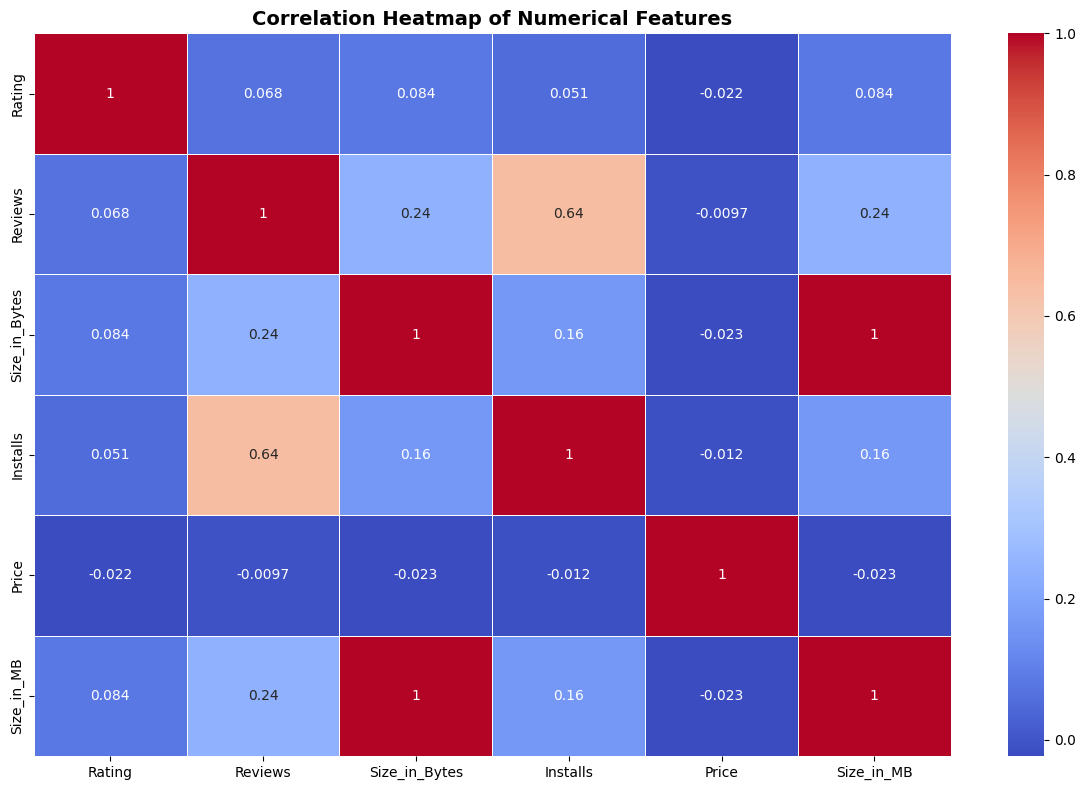

In [142]:
# ============================================
# Correlation Heatmap of Numerical Columns
# ============================================

# Set the figure size for better readability
plt.figure(figsize=(12, 8))

# Select the numerical columns for correlation analysis
numeric_cols = ['Rating', 'Reviews', 'Size_in_Bytes', 'Installs', 'Price', 'Size_in_MB']

# Plot the correlation matrix as a heatmap
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)

# Add a title for clarity
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the heatmap
plt.show()


In [143]:
# We can also calculate the correlation matrix using pandas (default = Pearson correlation)

df[numeric_cols].corr()

,Rating,Reviews,Size_in_Bytes,Installs,Price,Size_in_MB
Rating,1.000000,0.068147,0.084098,0.051393,-0.021851,0.084098
Reviews,0.068147,1.000000,0.238218,0.643123,-0.009666,0.238218
Size_in_Bytes,0.084098,0.238218,1.000000,0.164794,-0.023000,1.000000
Installs,0.051393,0.643123,0.164794,1.000000,-0.011688,0.164794
Price,-0.021851,-0.009666,-0.023000,-0.011688,1.000000,-0.023000
Size_in_MB,0.084098,0.238218,1.000000,0.164794,-0.023000,1.000000


In [144]:
# ==========================================================
# Calculate Pearson Correlation Coefficient using SciPy
# ==========================================================

from scipy import stats

# Drop rows containing NaN or infinite values 
# (important because Pearson's r requires complete pairs)
df_clean = df.dropna()

# Compute Pearson's correlation coefficient (r) between 'Reviews' and 'Installs'
pearson_r, _ = stats.pearsonr(df_clean['Reviews'], df_clean['Installs'])

# Display the result
print(f"Pearson's r between Reviews and Installs: {pearson_r:.4f}")

Pearson's r between Reviews and Installs: 0.6262


---
### **Observations:**

- The lighter (reddish) areas in the heatmap represent high positive correlations, whereas the darker (bluish) areas represent low or negative correlations.

- From the heatmap, we can clearly see that the `Reviews` column has a moderate to strong positive correlation with the `Installs` column, with a correlation coefficient of approximately 0.63 (based on corr()).
    - This indicates that apps with a higher number of installs tend to receive more reviews — a logical and expected trend.

    - Therefore, if we ever need to impute missing values in the `Reviews` column, it would make sense to consider the `Installs` values.

        - For instance, imputing a review count of `1000` for an app with only `2` installs would be unrealistic and misleading.

- The `Installs` column shows a weak positive correlation with `Size_in_MB` and `Size_in_Bytes` (around 0.16).

 - This suggests that while app size might have a slight influence on the number of installs, the relationship is not statistically strong enough to rely upon for imputation or inference.


---

- Before proceeding further, let's remove the rows with missing values in the `Current Ver`, `Android Ver`, `Category`, `Type`, and `Genres` columns, since the number of missing entries is minimal and their removal will not significantly impact the overall analysis.

In [145]:
# Display the length of the DataFrame before removing null values

print(f"Length of the DataFrame before removing null values: {len(df)}")

Length of the DataFrame before removing null values: 10841


In [146]:
# Remove rows with null values in 'Current Ver', 'Android Ver', 'Category', 'Type', and 'Genres' columns

df.dropna(subset=['Current Ver', 'Android Ver', 'Category', 'Type', 'Genres'], inplace=True)

In [147]:
# Display the length of the DataFrame after removing null values

print(f"Length of the DataFrame after removing null values: {len(df)}")

Length of the DataFrame after removing null values: 10829


- We have removed `12` rows containing missing values in the 
  `Current Ver`, `Android Ver`, `Category`, `Type`, and `Genres` columns.

In [148]:
# Verify the remaining null values in the dataset

df.isnull().sum().sort_values(ascending=False)

Size_in_Bytes        1694
Size_in_MB           1694
Rating               1469
Category                0
Reviews                 0
Installs                0
App                     0
Type                    0
Price                   0
Genres                  0
Content Rating          0
Last Updated            0
Current Ver             0
Android Ver             0
Installs_Category       0
dtype: int64

---
### **Observations**

- After cleaning, only the `Rating` and `Size_in_Bytes` / `Size_in_MB` columns still contain missing values.

    - We need to be cautious while handling the `Rating` column, as it is directly related to the number of `Installs`, and careless imputation could distort important relationships in the data.

    - The missing values in the Size columns correspond to apps where the size "Varies with device" — which we intentionally converted to nulls earlier.

        - These should not be imputed, since app size genuinely varies by device, and any artificial filling could reduce data accuracy.
    
---

In [149]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_in_Bytes', 'Installs',
       'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver', 'Size_in_MB', 'Installs_Category'],
      dtype='object')

In [150]:
# Use groupby() to analyze the distribution and trend of 'Rating' across each 'Installs_category'

df.groupby('Installs_Category')['Rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Installs_Category,,,,,,,,
No,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Very Low,81.0,4.637037,0.845199,1.0,4.8,5.0,5.0,5.0
Low,1278.0,4.170970,0.825605,1.0,3.8,4.4,4.8,5.0
Moderate,1440.0,4.035417,0.604428,1.4,3.8,4.2,4.5,5.0
More than Moderate,1616.0,4.093255,0.505619,1.6,3.9,4.2,4.5,4.9
High,2113.0,4.207525,0.376594,1.8,4.0,4.3,4.5,4.9
Very High,2004.0,4.287076,0.294902,2.0,4.1,4.3,4.5,4.9
Top Notch,828.0,4.374396,0.193726,3.1,4.3,4.4,4.5,4.8


In [151]:
# Total missing ratings

df['Rating'].isnull().sum()

np.int64(1469)

In [152]:
# How missing Ratings are distributed across 'Installs_Category'

df['Installs_Category'].loc[df['Rating'].isnull()].value_counts()

Installs_Category
Low                   880
Very Low              453
Moderate               88
More than Moderate     31
No                     14
High                    3
Very High               0
Top Notch               0
Name: count, dtype: int64

- Let's visualize the distribution of Ratings across each Installs Category


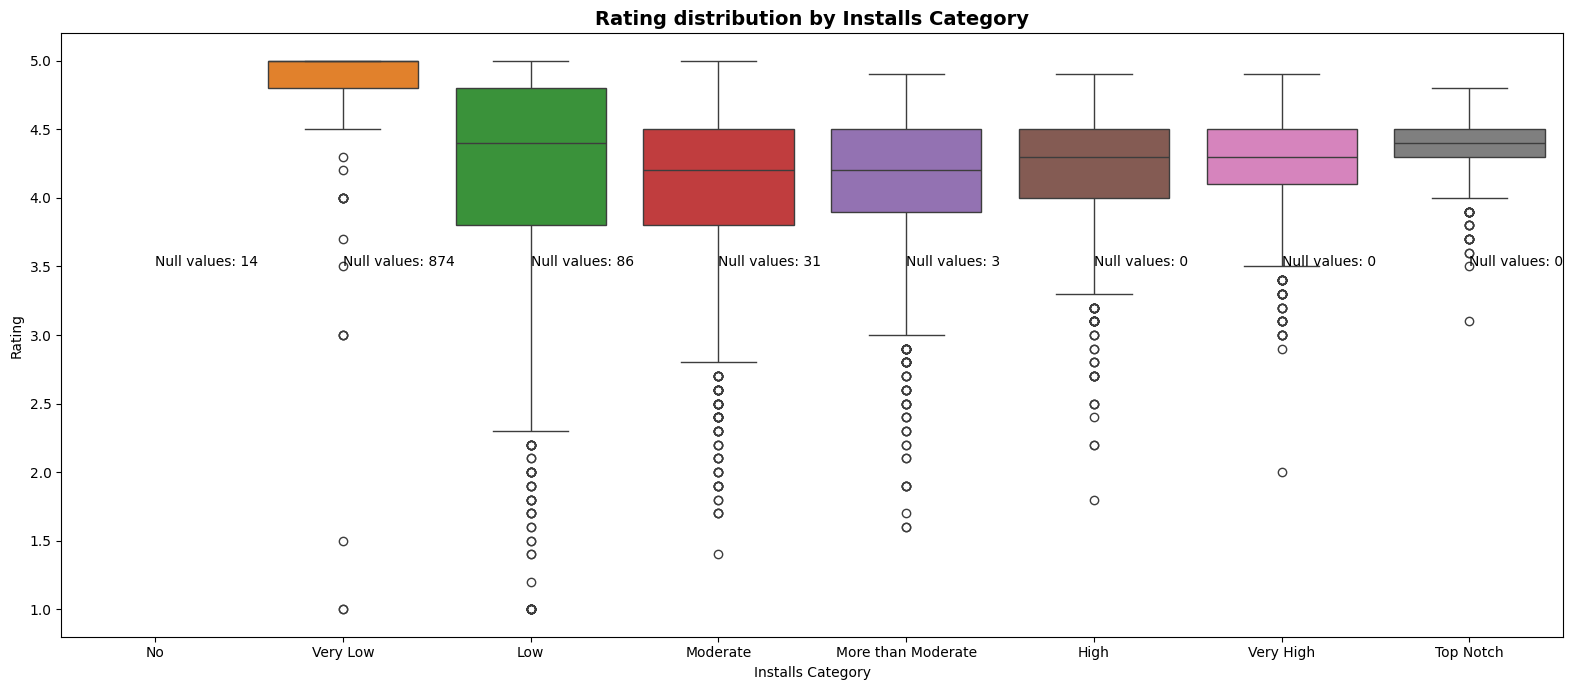

In [153]:
# Plot the boxplot of Rating in each Installs Category
plt.figure(figsize=(16,7))

sns.boxplot(x='Installs_Category', y='Rating', hue='Installs_Category', data=df)

# Add title and labels
plt.title("Rating distribution by Installs Category", fontsize=14, fontweight='bold')
plt.xlabel("Installs Category")
plt.ylabel("Rating")

# --- Add the number of null values text for each category ---
plt.text(0, 3.5, 'Null values: 14')
plt.text(1, 3.5, 'Null values: 874')
plt.text(2, 3.5, 'Null values: 86')
plt.text(3, 3.5, 'Null values: 31')
plt.text(4, 3.5, 'Null values: 3')
plt.text(5, 3.5, 'Null values: 0')
plt.text(6, 3.5, 'Null values: 0')
plt.text(7, 3.5, 'Null values: 0')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


### **Interpretation:**

- Trend:
As installation categories move from “Low” -> “Top Notch”, the median rating increases slightly and the variation decreases.

    - “Low” and “Moderate” categories have more spread (ratings vary a lot).

    - “Top Notch” apps have high and consistent ratings — indicating user satisfaction.

- Outliers:
    - Many low-rating outliers exist in “Low” and “Moderate” categories.
    - These may represent poor or buggy apps with fewer users.

- Null Value Labels:
    - Each text label (e.g., “Null values: 874”) tells how many apps in that category are missing ratings (i.e., Rating = NaN).
---

### Next Step: Imputing Missing Values in the `Rating` Column

After understanding the relationship between `Installs_Category` and `Rating` through descriptive statistics and boxplots,
we’ll now impute missing ratings based on the average rating of each install category.

In [154]:
# Replace missing 'Rating' values with the mean of their respective 'Installs_Category'

df['Rating'] = df['Rating'].fillna(
    df.groupby('Installs_Category')['Rating'].transform('mean').round(2))

In [155]:
# Check if any nulls left in Rating column

df['Rating'].isnull().sum()

np.int64(14)

In [156]:
# Identify which 'Installs_Category' still contain null ratings

df['Installs_Category'].loc[df['Rating'].isnull()].value_counts()

Installs_Category
No                    14
Very Low               0
Low                    0
Moderate               0
More than Moderate     0
High                   0
Very High              0
Top Notch              0
Name: count, dtype: int64

- All missing ratings belong to the “No Installs” category.

In [157]:
# Check which apps belong to this “No Installs” category

df[df['Installs_Category'] == 'No']

,App,Category,Rating,Reviews,Size_in_Bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_MB,Installs_Category
4465,Popsicle Launcher for Android P 9.0 launcher,PERSONALIZATION,NaN,0,5767168.0,0,Paid,1.49,Everyone,Personalization,11-Jul-18,1.1,4.2 and up,5.5,No
5307,Ak Parti Yardım Toplama,SOCIAL,NaN,0,9122611.2,0,Paid,13.99,Teen,Social,28-Jul-17,3.4.4.3.3,4.1 and up,8.7,No
5486,AP Series Solution Pro,FAMILY,NaN,0,7759462.4,0,Paid,1.99,Everyone,Education,30-Jul-17,1.3,4.0 and up,7.4,No
5945,Ain Arabic Kids Alif Ba ta,FAMILY,NaN,0,34603008.0,0,Paid,2.99,Everyone,Education,15-Apr-16,1,3.0 and up,33.0,No
6692,cronometra-br,PRODUCTIVITY,NaN,0,5662310.4,0,Paid,154.99,Everyone,Productivity,24-Nov-17,1.0.0,4.1 and up,5.4,No
7434,Pekalongan CJ,SOCIAL,NaN,0,6186598.4,0,Free,0.00,Teen,Social,21-Jul-18,0.0.1,4.4 and up,5.9,No
8081,CX Network,BUSINESS,NaN,0,10485760.0,0,Free,0.00,Everyone,Business,6-Aug-18,1.3.1,4.1 and up,10.0,No
8614,Sweden Newspapers,NEWS_AND_MAGAZINES,NaN,0,2202009.6,0,Free,0.00,Everyone,News & Magazines,7-Jul-18,1.1,4.4 and up,2.1,No
8871,Test Application DT 02,ART_AND_DESIGN,NaN,0,1258291.2,0,Free,0.00,Everyone,Art & Design,14-Mar-17,4,4.2 and up,1.2,No
9337,EG | Explore Folegandros,TRAVEL_AND_LOCAL,NaN,0,58720256.0,0,Paid,3.99,Everyone,Travel & Local,22-Jan-17,1.1.1,4.1 and up,56.0,No


- Found 14 apps with 0 installs, 0 reviews, and missing ratings.

In [158]:
# Check the proportion of each Install Category

df['Installs_Category'].value_counts(normalize=True) * 100

Installs_Category
Low                   19.927971
High                  19.540124
Very High             18.505864
More than Moderate    15.209161
Moderate              14.110259
Top Notch              7.646135
Very Low               4.931203
No                     0.129282
Name: proportion, dtype: float64

- The “No Installs” category contributes only 0.13% of the dataset.

In [159]:
# Drop rows where Installs_Category = 'No'

df = df[df['Installs_Category'] != 'No']

In [160]:
# Verify again

df['Installs_Category'].value_counts(normalize=True) * 100

Installs_Category
Low                   19.953768
High                  19.565418
Very High             18.529820
More than Moderate    15.228849
Moderate              14.128525
Top Notch              7.656033
Very Low               4.937587
No                     0.000000
Name: proportion, dtype: float64

- The “No Installs” category has been completely removed.

---
### **Observations:**

- Initially, we replaced missing ratings using the mean rating of each `Installs_Category` to maintain logical consistency — apps with similar install levels are expected to have similar rating behavior.

- After imputation, only 14 ratings were still missing, all from the “No Installs” category.

- On closer inspection, these apps had:

    - 0 installs,

    - 0 reviews, and

    - missing ratings, meaning they were never used or rated by any user.

- Since they formed only 0.13% of the total dataset and contributed no analytical value, we removed them instead of imputing arbitrary values.

- This approach ensures that:

    - We preserve data quality and logical consistency — only active, rated apps remain.

    - The analysis reflects real-world user engagement (installs - ratings relationship).

    - The dataset becomes cleaner and more reliable for further correlation and trend analysis.

---

In [161]:
# Let's check if there are any missing values in the 'Reviews' column

df['Installs_Category'].loc[df['Reviews'].isnull()].value_counts()

Installs_Category
No                    0
Very Low              0
Low                   0
Moderate              0
More than Moderate    0
High                  0
Very High             0
Top Notch             0
Name: count, dtype: int64


- There are no missing values in the 'Reviews' column across any install category — good data quality here.

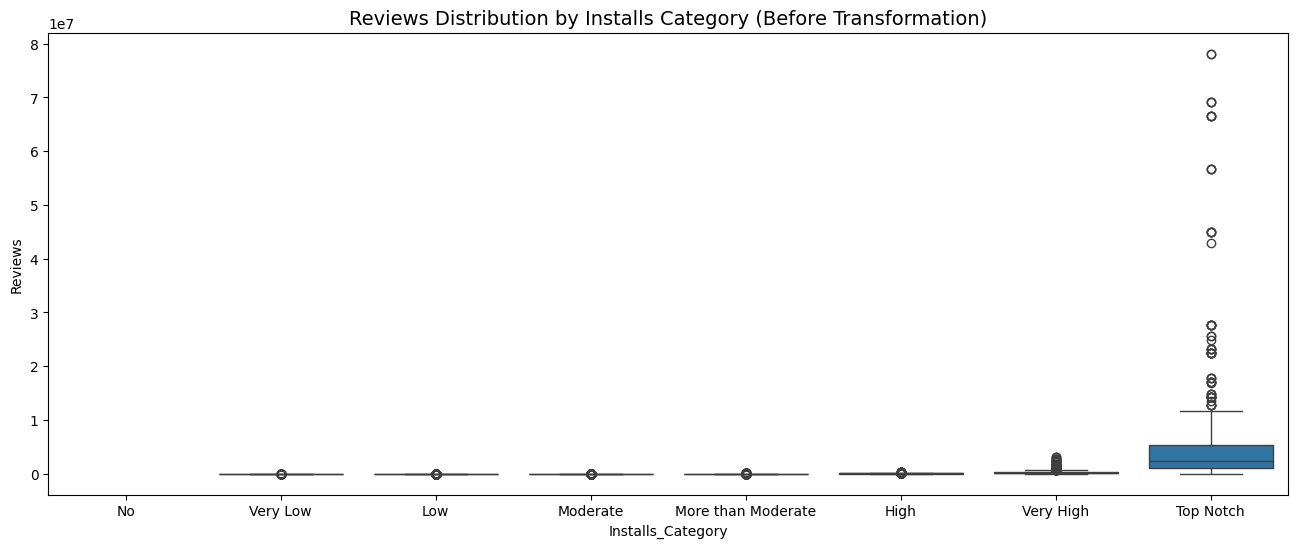

In [162]:
# Check Reviews distribution by Installs Category

plt.figure(figsize=(16,6))
sns.boxplot(x='Installs_Category', y='Reviews', data=df)
plt.title('Reviews Distribution by Installs Category (Before Transformation)', fontsize=14)
plt.show()

#### Observation:
- Data is highly skewed due to extreme outliers.
- Most apps have few reviews, while a few have millions (Top Notch).
- Lower categories appear compressed and not interpretable.

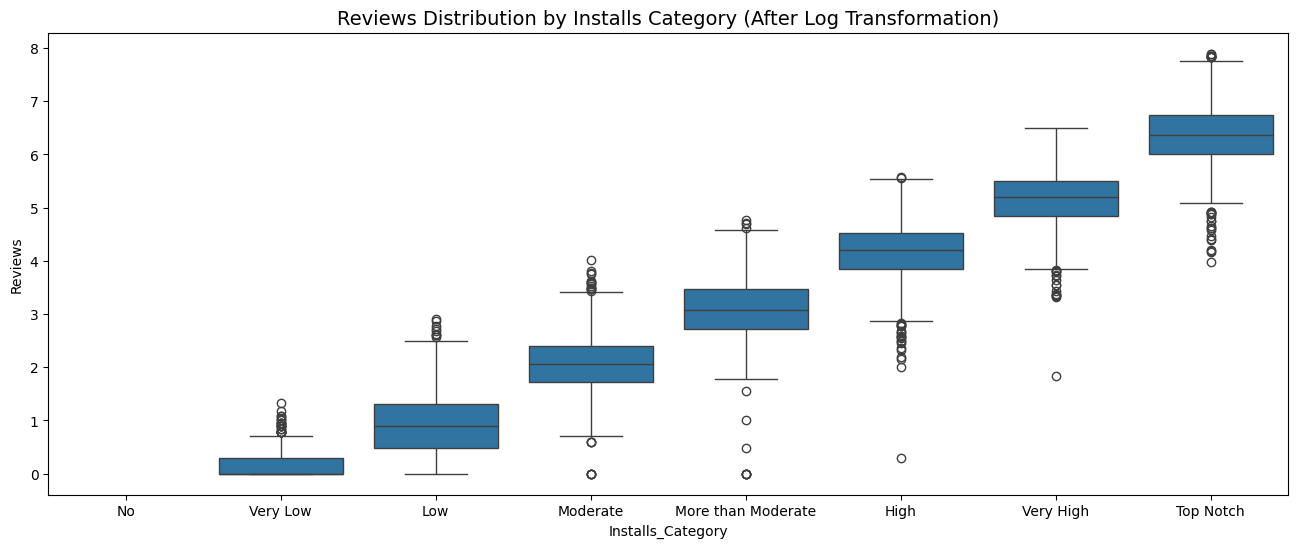

In [163]:
# Apply Log Transformation to handle skewness

plt.figure(figsize=(16,6))
sns.boxplot(x='Installs_Category', y=np.log10(df['Reviews'] + 1), data=df)  # added +1 to handle zero values safely
plt.title("Reviews Distribution by Installs Category (After Log Transformation)", fontsize=14)
plt.show()

#### Observations:
- Log transformation normalizes the distribution.
- Clear increasing trend: more installs -> more reviews.
- Skewness reduced, outliers less dominant.
- Using log10 helps handle wide numeric range and interpretability.
---

#### Exploring the Relationship Between Ratings, Reviews, and Installs

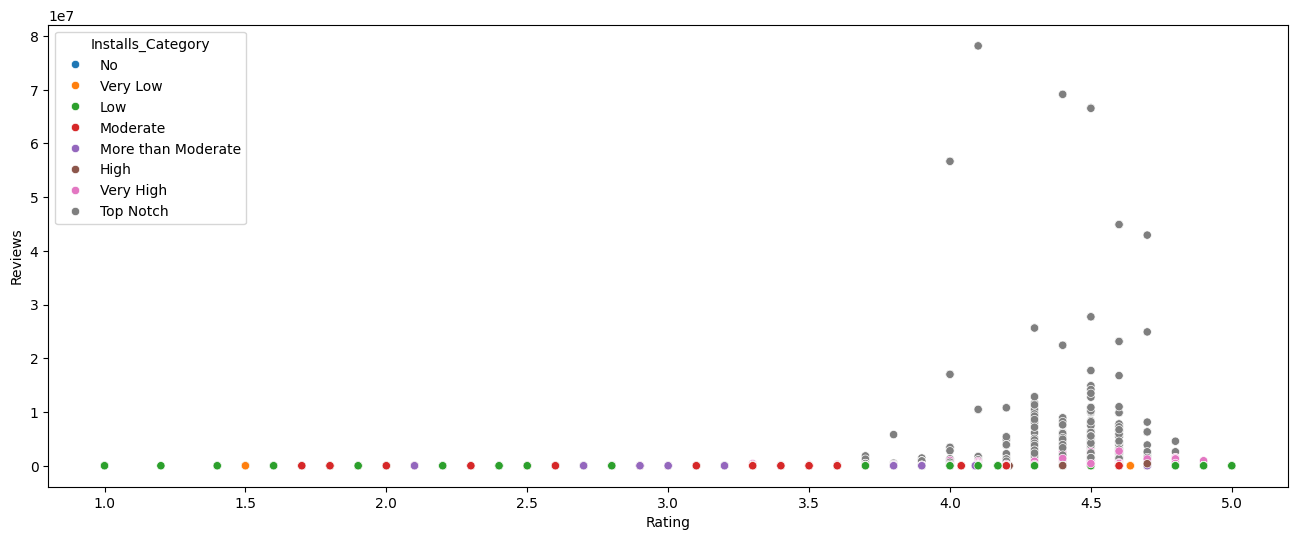

In [164]:
# Step 1: Scatter Plot — Rating vs Reviews by Installs_Category

plt.figure(figsize=(16,6))
sns.scatterplot(x='Rating', y='Reviews', hue='Installs_Category', data=df)
plt.show()

#### Observation:

- There’s no visible trend between Rating and Reviews.
- This is expected — Rating is an ordinal categorical variable (ranging 1–5), while Reviews is continuous.
- Hence, scatter plots between these types of variables don’t usually show linear relationships.

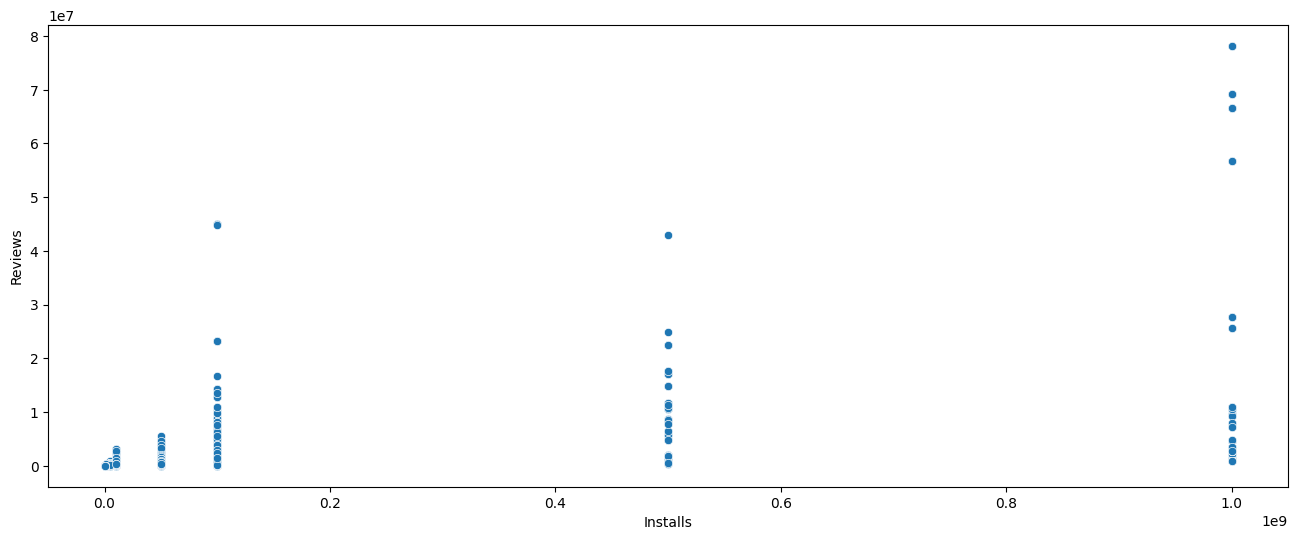

In [165]:
# Step 2: Scatter Plot — Reviews vs. Installs

plt.figure(figsize=(16,6))
sns.scatterplot(x='Installs', y='Reviews', data=df)
plt.show()

#### Observations: Relationship between Installs and Reviews (Before Log Transformation)

- The data is highly skewed — most apps have relatively few installs and reviews, while a small number dominate with millions or even billions of installs.

- Because of this extreme scale difference, the data points are densely compressed near the origin, making smaller apps hard to distinguish.

- Despite this, a rough positive relationship is visible — apps with more installs generally receive more reviews.

- The discrete install brackets (e.g., 10+, 1000+, 1M+, 1B+) cause distinct vertical lines, rather than a smooth gradient of points.

- Hence, applying a log transformation is essential to better visualize and compare apps across different popularity levels.

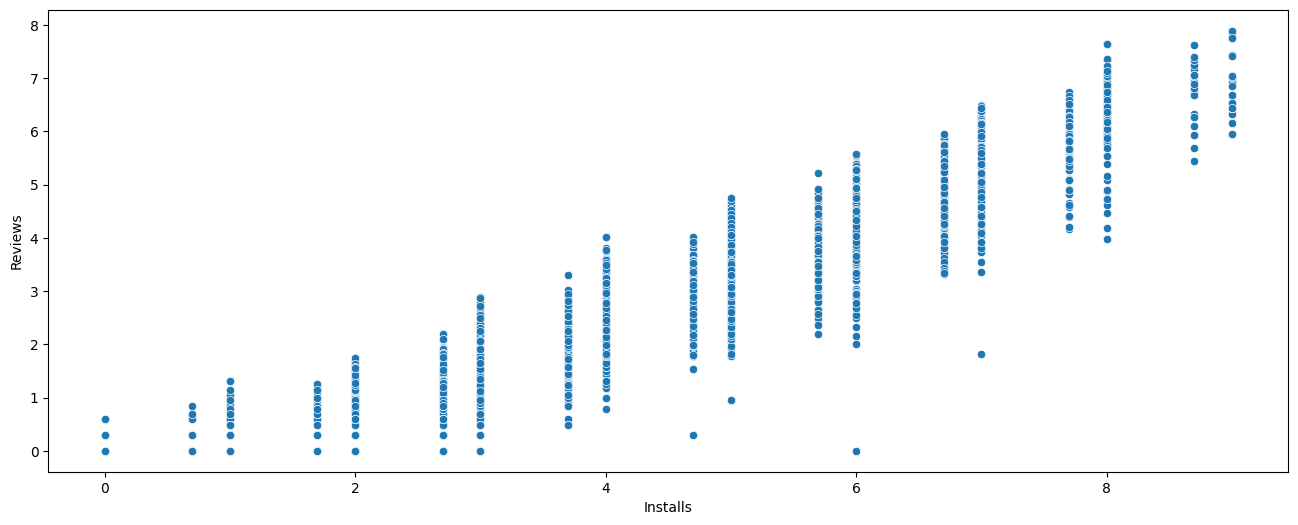

In [166]:
# Step 3: Applying Log Transformation

plt.figure(figsize=(16,6))
sns.scatterplot(x=np.log10(df['Installs']), y=np.log10(df['Reviews']), data=df)
plt.show()

#### Observations: Relationship between Installs and Reviews (After Log Transformation)

- After applying log10, the data becomes more linear and evenly distributed, minimizing the skew caused by large-scale differences.

- A strong positive linear relationship emerges — as installs increase, reviews tend to rise proportionally on a logarithmic scale.

- The step-like pattern seen earlier smooths out, making the progression between different install levels more natural and interpretable.

- This transformation makes it easier to spot consistent proportional growth between installs and reviews across small and large apps.

- In summary, log-scaling helps normalize extreme values and reveal a clearer relationship between the two metrics.

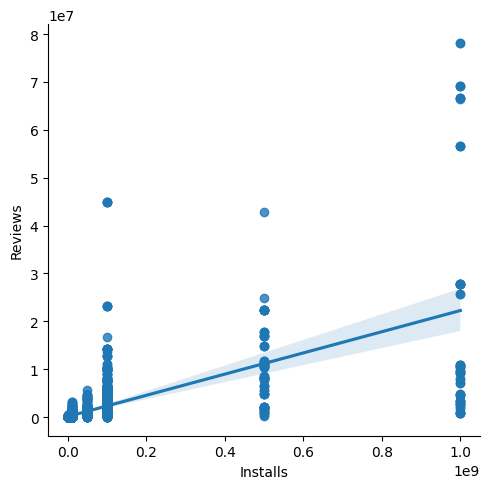

In [167]:
# Step 4: Regression (Trend Line)

sns.lmplot(x='Installs', y='Reviews', data=df, height=5, aspect=1)
plt.show()

#### Overall Interpretation:

- There is a clear positive correlation between installs and reviews — more installs generally lead to more user feedback.

- However, the relationship is not perfectly linear; some apps have high installs but relatively few reviews, indicating differences in user engagement or review behavior.

- The variance (spread of points) suggests that even within the same install category, user review activity can vary widely by app type or user base.

- Overall, the trend confirms that install growth drives review growth, but the strength of this relationship depends on other factors like app category, rating experience, and user motivation to review.

---
### **Observation Summary**

- Most apps with fewer installations tend to have missing or very few ratings and reviews, which aligns with user engagement behavior.

- After imputing missing `Rating` values based on install categories, the data became more balanced and suitable for further analysis.

- Scatter plots showed a positive relationship between installs and reviews — apps with higher installs generally receive more user feedback.

- The spread in points indicates that even within the same install category, user engagement levels can vary depending on app type or audience.

Now that missing values and initial relationships are analyzed, we move to check for duplicate records to ensure data consistency.


---
### **2.3 Handling Duplicates**

- Identifying and removing duplicates is a crucial step in ensuring the dataset’s integrity.

- Duplicate entries can lead to biased or misleading insights, as certain records might be overrepresented in the analysis.

- They can also distort statistical summaries such as mean, median, and standard deviation.

- Therefore, removing duplicates ensures the analysis reflects unique and accurate observations of each app.

##### Checking for duplicate rows

In [168]:
df.duplicated().sum()

np.int64(483)

The above count reflects total duplicate rows across all columns.
However, since each app should ideally have a unique name, let’s specifically check for duplicates in the App column.

In [169]:
df['App'].duplicated().sum()

np.int64(1181)

- We have 1181 duplicate app names, meaning several apps appear more than once.
- To better understand duplication across columns, let’s inspect each one:

In [170]:
# Check duplicate counts for each column
for col in df.columns:
    print(f"{col}: {df[col].duplicated().sum()} duplicates")

App: 1181 duplicates
Category: 10782 duplicates
Rating: 10771 duplicates
Reviews: 4816 duplicates
Size_in_Bytes: 10359 duplicates
Installs: 10796 duplicates
Type: 10813 duplicates
Price: 10727 duplicates
Content Rating: 10809 duplicates
Genres: 10696 duplicates
Last Updated: 9440 duplicates
Current Ver: 8034 duplicates
Android Ver: 10782 duplicates
Size_in_MB: 10359 duplicates
Installs_Category: 10808 duplicates


From the output, duplication exists across most columns, but the App column provides the clearest indicator of record-level duplication.

In [171]:
# Verifying complete-row duplicates

print(f"Number of full-row duplicates: {df.duplicated().sum()}")

Number of full-row duplicates: 483


Reviewing duplicates

In [172]:
df[df['App'].duplicated(keep=False)].sort_values(by='App')

,App,Category,Rating,Reviews,Size_in_Bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_MB,Installs_Category
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.00,2490,3984588.8,500000,Free,0.00,Everyone 10+,Health & Fitness,17-Feb-17,1.9,2.3.3 and up,3.800000,High
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.00,2490,3984588.8,500000,Free,0.00,Everyone 10+,Health & Fitness,17-Feb-17,1.9,2.3.3 and up,3.800000,High
2543,1800 Contacts - Lens Store,MEDICAL,4.70,23160,27262976.0,1000000,Free,0.00,Everyone,Medical,27-Jul-18,7.4.1,5.0 and up,26.000000,High
2322,1800 Contacts - Lens Store,MEDICAL,4.70,23160,27262976.0,1000000,Free,0.00,Everyone,Medical,27-Jul-18,7.4.1,5.0 and up,26.000000,High
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.40,12,3984588.8,1000,Paid,16.99,Everyone,Medical,27-Jan-17,1.0.5,4.0.3 and up,3.800000,Low
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.40,12,3984588.8,1000,Paid,16.99,Everyone,Medical,27-Jan-17,1.0.5,4.0.3 and up,3.800000,Low
1337,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.40,11506,15728640.0,100000,Free,0.00,Everyone,Health & Fitness,2-Aug-18,3.0.0,4.1 and up,15.000000,More than Moderate
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.40,11506,15728640.0,100000,Free,0.00,Everyone,Health & Fitness,2-Aug-18,3.0.0,4.1 and up,15.000000,More than Moderate
3083,365Scores - Live Scores,SPORTS,4.60,666521,26214400.0,10000000,Free,0.00,Everyone,Sports,29-Jul-18,5.5.9,4.1 and up,25.000000,Very High
5415,365Scores - Live Scores,SPORTS,4.60,666246,26214400.0,10000000,Free,0.00,Everyone,Sports,29-Jul-18,5.5.9,4.1 and up,25.000000,Very High


This helps identify whether duplicates are truly identical or slightly different (e.g., same app but different categories, reviews, or update versions).

Removing exact duplicates

In [173]:
# Remove exact duplicate rows
df.drop_duplicates(inplace=True)

# Verify dataset size after cleanup
print(f"Number of rows after removing exact duplicates: {df.shape[0]}")

Number of rows after removing exact duplicates: 10332


#### **Handling Near-Duplicates (Same App, Slight Variations)**

- Upon closer inspection, several apps appeared multiple times with slight variations — such as differences in category or review counts.

- These represent near-duplicates likely caused by multiple data scrapes or version updates in the Play Store.

- To ensure each app is represented only once and reflects the most relevant version, we will retain the record with the highest number of reviews per app, assuming it corresponds to the most popular or latest version.

In [174]:
# Step 1: Sort so that the highest review count per app comes first
df = df.sort_values('Reviews', ascending=False)

# Step 2: Drop duplicates based on 'App', keeping only the first (highest Reviews)
df = df.drop_duplicates(subset='App', keep='first')

# Step 3: Reset index for clean output
df.reset_index(drop=True, inplace=True)

# Step 4: Verify results
print(f"Remaining unique apps: {df['App'].nunique()}")
print(f"Total rows after cleanup: {df.shape[0]}")

Remaining unique apps: 9634
Total rows after cleanup: 9634


#### **Observations — Duplicate Handling**

- 483 exact duplicate records were identified and removed, reducing the dataset to 10,332 unique app entries.

- Further inspection revealed additional near-duplicates (e.g., 8 Ball Pool, A&E – Watch Full Episodes) with identical app names but slight differences in category, reviews, or metadata.

- To ensure data accuracy and represent only the most relevant version of each app, we retained the record with the highest number of reviews — assuming it corresponds to the most popular or latest version.

- After this final refinement, the dataset now contains 9,634 unique apps, each represented by a single, most relevant record.

- This step ensures clean, unbiased statistical summaries and reliable correlation or trend analysis moving forward.
---

## **3. Insights from Data**

### **3.1. Which category has the highest number of apps?**

Category
FAMILY      1870
GAME         946
TOOLS        827
BUSINESS     419
MEDICAL      394
Name: count, dtype: int64


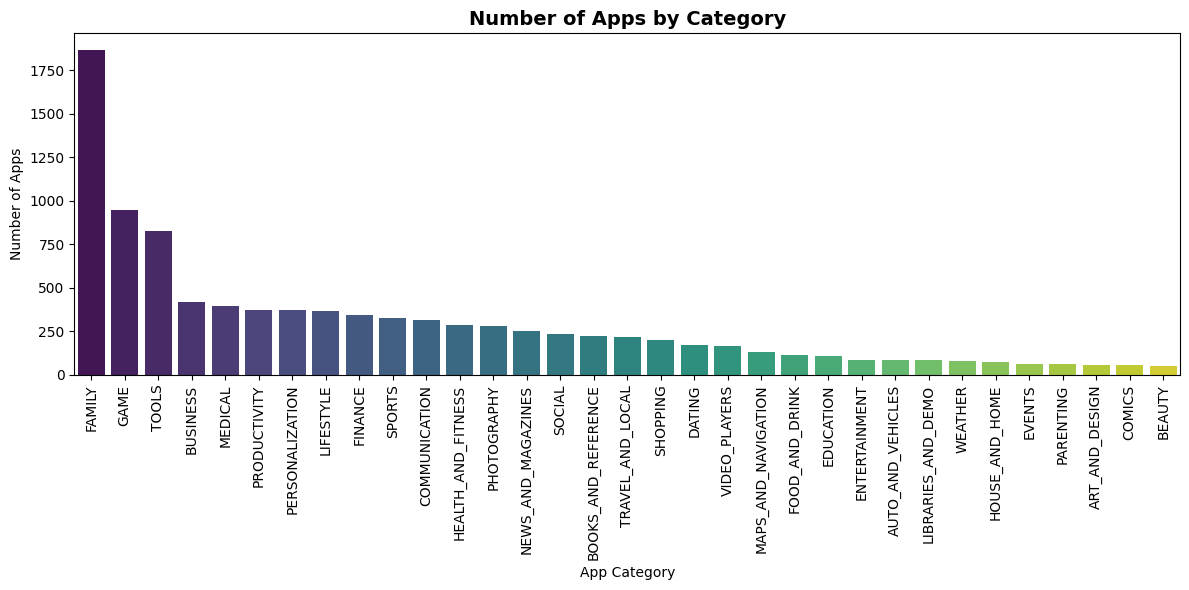

In [175]:
# Count number of apps in each category
category_counts = df['Category'].value_counts()

# Display the top categories
print(category_counts.head())

# Plot it for better understanding
plt.figure(figsize=(12,6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.xticks(rotation=90)
plt.title("Number of Apps by Category", fontsize=14, fontweight='bold')
plt.xlabel("App Category")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

#### **Observations**

- The `Family` category has the highest number of apps, with nearly 1,900 apps, indicating that developers heavily focus on entertainment, learning, and engagement for all age groups.

- `Game` apps come next, reflecting the strong user demand and profitability in the gaming industry.

- Utility-based categories like `Tools`, `Business`, and `Medical` also have a large number of apps, showing that practical and productivity-focused solutions are popular among developers.

- Categories such as `Beauty`, `Comics`, and `Parenting` have comparatively fewer apps, suggesting they cater to niche audiences.

- Overall, the app market is dominated by family-oriented and entertainment-based apps, but there’s a healthy mix of business and productivity applications too.

### **3.2. Which category has the highest number of installs?**

Category
GAME                  13457924415
COMMUNICATION         11038276251
TOOLS                  8102271905
FAMILY                 6226482405
PRODUCTIVITY           5793091369
SOCIAL                 5487867902
PHOTOGRAPHY            4658147655
VIDEO_PLAYERS          3931902720
TRAVEL_AND_LOCAL       2894887146
NEWS_AND_MAGAZINES     2369217760
Name: Installs, dtype: int64


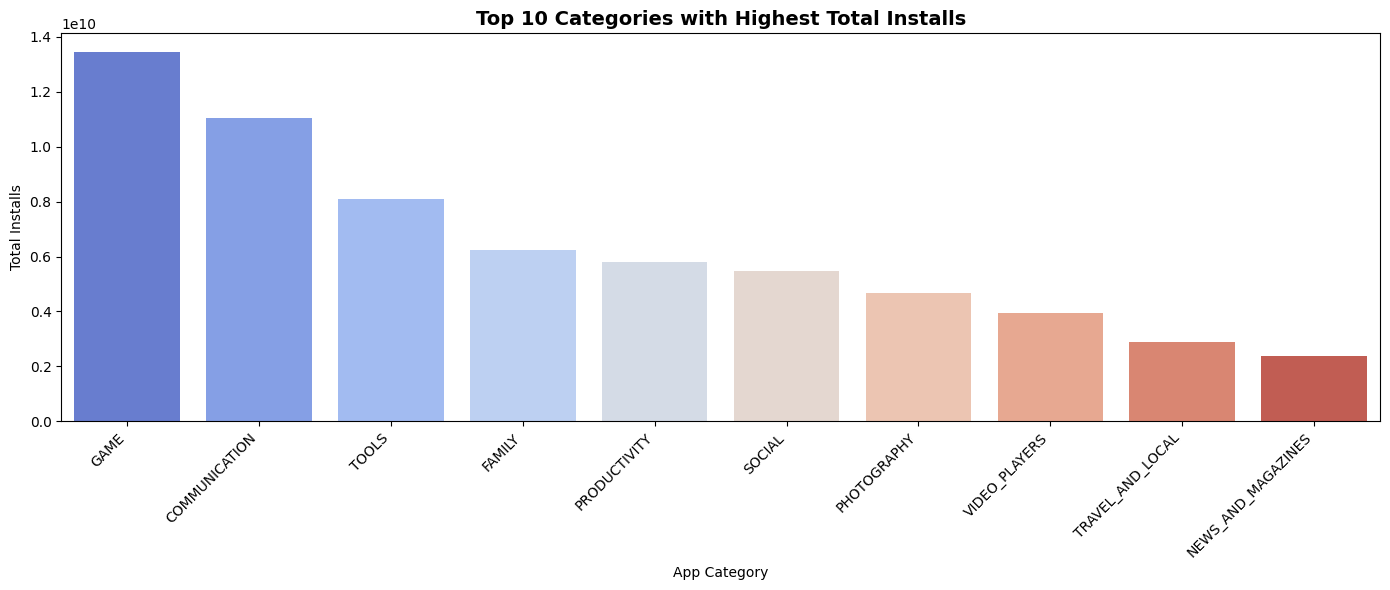

In [176]:
# Group by Category and sum the total installs for each category
category_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False)

# Display the top categories
print(category_installs.head(10))

# Plot the top 10 categories by total installs
plt.figure(figsize=(14,6))
sns.barplot(x=category_installs.head(10).index, y=category_installs.head(10).values, palette='coolwarm')
plt.title('Top 10 Categories with Highest Total Installs', fontsize=14, fontweight='bold')
plt.xlabel('App Category')
plt.ylabel('Total Installs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **Observations**

- The `Game` category dominates app installs, exceeding 13 billion downloads, showing that entertainment-based apps attract the largest audience on the Play Store.

- `Communication` apps rank second, with over 11 billion installs, emphasizing users’ strong dependence on messaging, calling, and social interaction apps.

- `Tools`, `Family`, and `Productivity` apps follow — these are typically utility-based, indicating users also value functionality and everyday usefulness.

- Lower down, categories like `Photography`, `Video Players`, and `Travel & Local` still have solid install numbers but appeal to niche or purpose-specific audiences.

- Overall, the data highlights that gaming and communication apps dominate user downloads, while utility and lifestyle apps form the second layer of user preference.
---

### **3.3. Which category has the highest number of reviews?**

Category
GAME               590772190
COMMUNICATION      285824082
TOOLS              229467619
SOCIAL             227936355
FAMILY             193600629
PHOTOGRAPHY        105580472
VIDEO_PLAYERS       67644444
PRODUCTIVITY        55590856
PERSONALIZATION     53542698
SHOPPING            44554067
Name: Reviews, dtype: int64


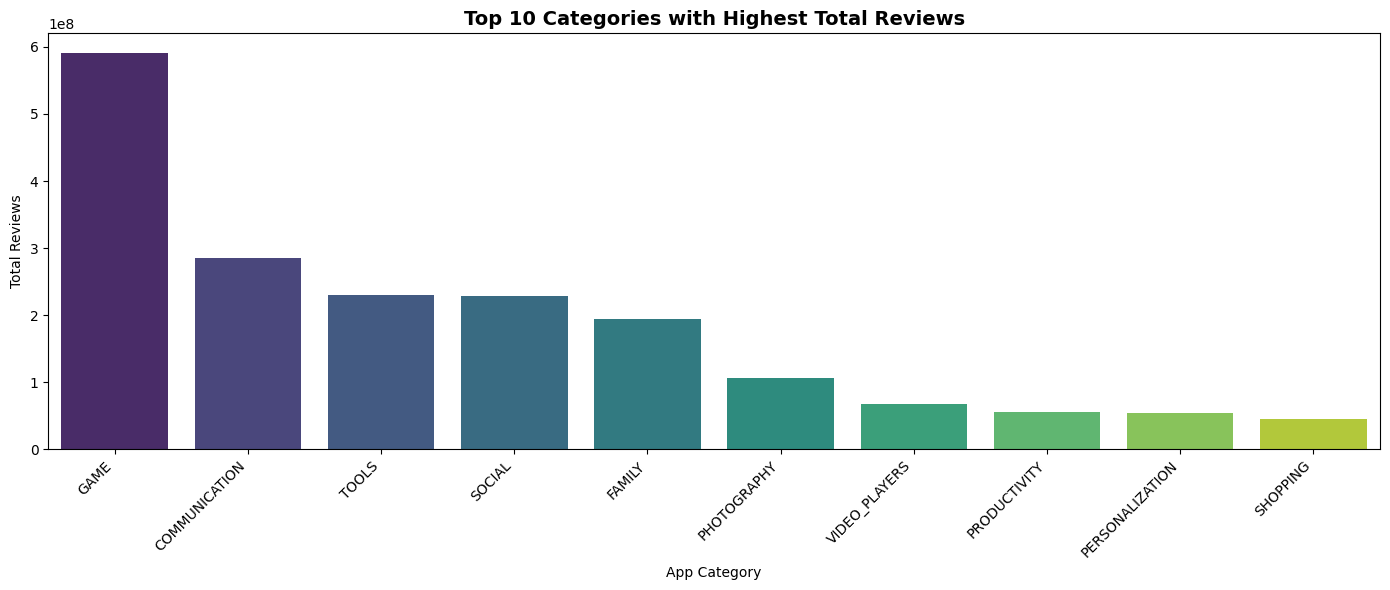

In [177]:
# Group by Category and sum the total reviews for each category
category_reviews = df.groupby('Category')['Reviews'].sum().sort_values(ascending=False)

# Display the top categories
print(category_reviews.head(10))

# Plot the top 10 categories by total reviews
plt.figure(figsize=(14,6))
sns.barplot(x=category_reviews.head(10).index, y=category_reviews.head(10).values, palette='viridis')
plt.title('Top 10 Categories with Highest Total Reviews', fontsize=14, fontweight='bold')
plt.xlabel('App Category')
plt.ylabel('Total Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **Observations**
- The ‘Game’ category dominates with the highest total number of reviews, far surpassing all other categories — showing that games attract the most user engagement and feedback.

- ‘Communication’, ‘Tools’, and ‘Social’ apps follow next, highlighting that apps related to daily use and connectivity also have high user interaction.

- ‘Family’ and ‘Photography’ categories have moderate review volumes, suggesting steady but less intensive engagement compared to games and communication apps.

- The lower-ranked categories like ‘Productivity’ and ‘Shopping’ still maintain consistent activity, showing user reliance but not as much active feedback.

- Overall, the trend shows that apps built for entertainment, communication, and social connection generate the most user reviews, indicating stronger user involvement in those areas.
---

### **3.4. Which category has the highest rating?**

Category
EVENTS                 4.39
ART_AND_DESIGN         4.37
BOOKS_AND_REFERENCE    4.36
EDUCATION              4.35
PERSONALIZATION        4.33
PARENTING              4.26
HEALTH_AND_FITNESS     4.26
SOCIAL                 4.25
WEATHER                4.25
SPORTS                 4.25
Name: Rating, dtype: float64


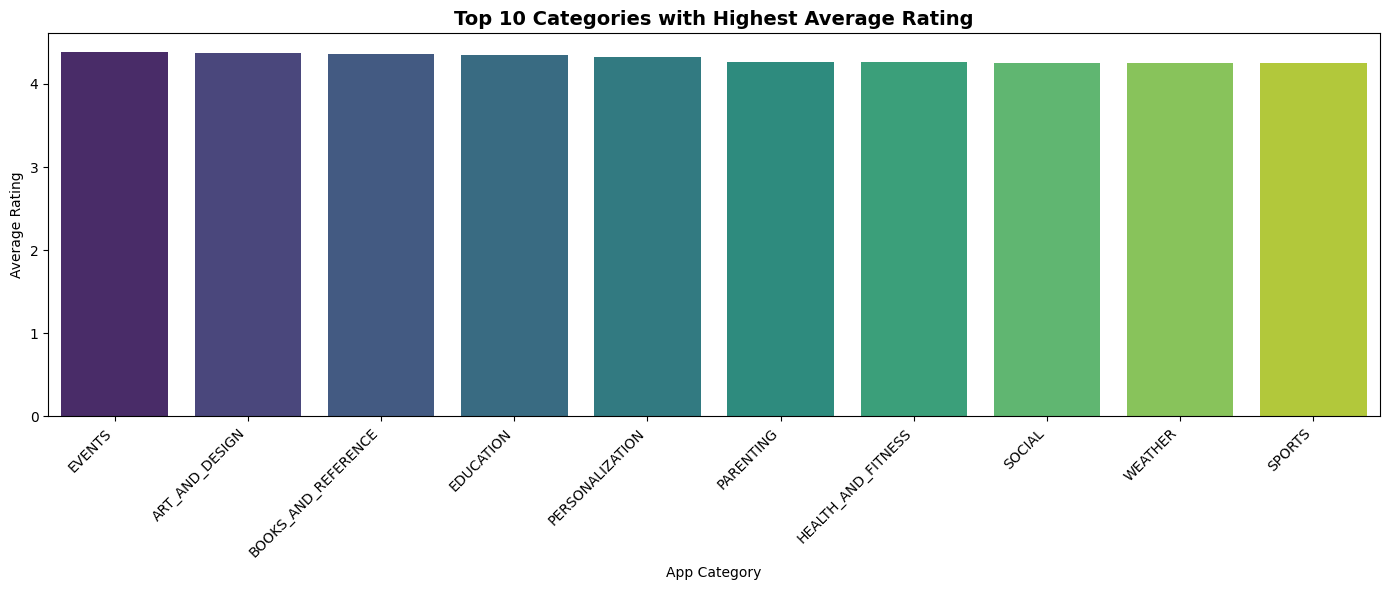

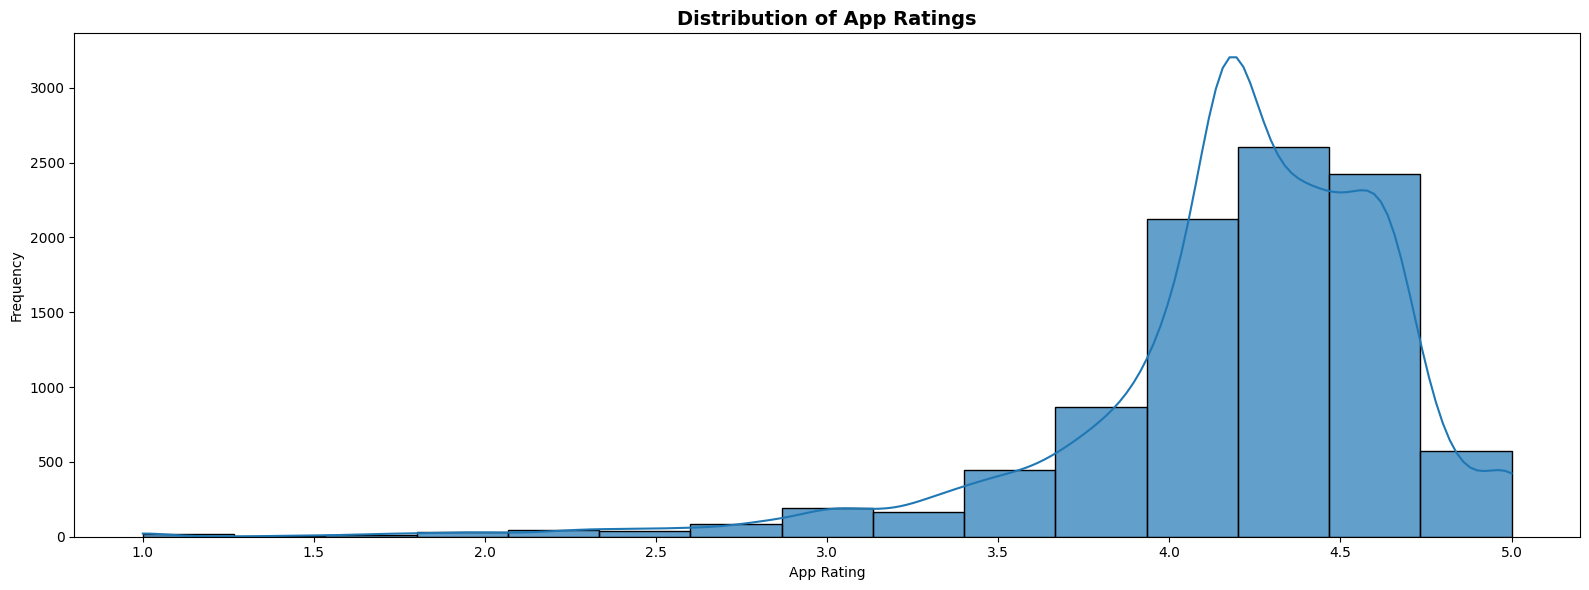

In [178]:
# Group by Category and calculate the average rating
category_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).round(2)

print(category_rating.head(10))  # Top categories by rating

# Plot category-level average
plt.figure(figsize=(14,6))
sns.barplot(x=category_rating.head(10).index, y=category_rating.head(10).values, palette='viridis')
plt.title('Top 10 Categories with Highest Average Rating', fontsize=14, fontweight='bold')
plt.xlabel('App Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot overall rating distribution
plt.figure(figsize=(16,6))
sns.histplot(df['Rating'], bins=15, kde=True, alpha=0.7)
plt.title('Distribution of App Ratings', fontsize=14, fontweight='bold')
plt.xlabel('App Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### **Observations**

1. Category-Level Insights

    - The ‘Events’, ‘Art & Design’, and ‘Books & Reference’ categories have the highest average user ratings (around 4.4–4.5), indicating strong user satisfaction.

    - Most top-rated categories are content- or creativity-focused, suggesting users value apps that provide learning, personalization, or artistic experiences.

    - Categories like Education and Health & Fitness also perform well, reflecting consistent quality and engagement.

2. Overall App Rating Trend

    - The majority of apps are rated between 4.0 and 4.5, showing that users tend to give favorable reviews overall.

    - Very few apps have ratings below 3.0, suggesting that poor-quality apps are less common or quickly removed.

    - The slight right skew in the histogram means that while most apps are well-rated, a small number still receive lower feedback.

3. Key Takeaway

    - Across the Play Store, users are generally satisfied, with most apps maintaining ratings above 4.0.

    - Quality-focused and utility-driven categories (like Education, Art, and Personalization) tend to achieve the best user feedback.

### **3.5. Which category generates the highest total revenue (Paid Apps)?**

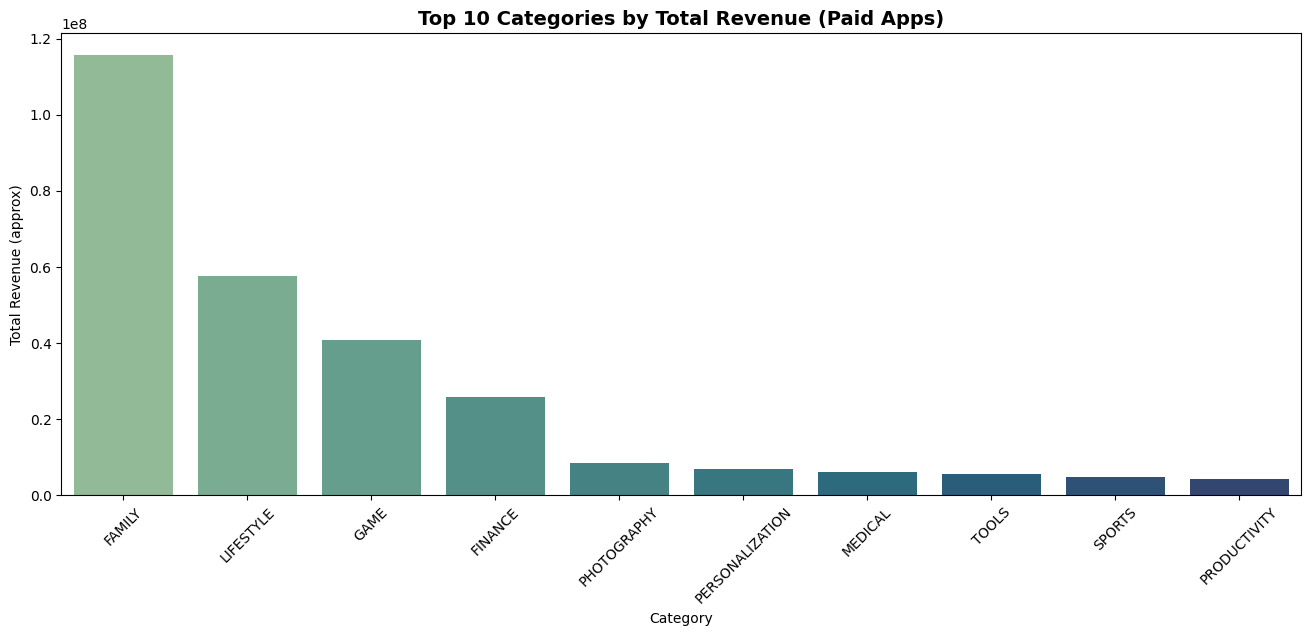

In [179]:
# Filter only paid apps and calculate revenue = Installs * Price
df_paid = df[df['Type'] == 'Paid'].copy()
df_paid['Revenue'] = df_paid['Installs'] * df_paid['Price']

# Group by Category
revenue_by_category = df_paid.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(16,6))
sns.barplot(x=revenue_by_category.index[:10], y=revenue_by_category.values[:10], palette='crest')
plt.title('Top 10 Categories by Total Revenue (Paid Apps)', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Revenue (approx)')
plt.xticks(rotation=45)
plt.show()

#### **Observations**

- The Family category dominates revenue generation among paid apps, contributing over twice as much as the next category.

- Lifestyle and Game categories follow, showing that users are willing to pay for apps that offer personal value or entertainment.

- Categories like Finance, Photography, and Personalization also generate significant revenue, likely due to premium features or niche utilities.

- On the other hand, technical or productivity-focused categories (Tools, Sports, Productivity) generate comparatively lower revenue, suggesting they rely more on free or freemium models.

- Overall, the paid app market is skewed toward family and lifestyle-oriented apps, where perceived usefulness or enjoyment encourages users to pay.
---

### **3.6. Do Free Apps have better ratings than Paid Apps?**

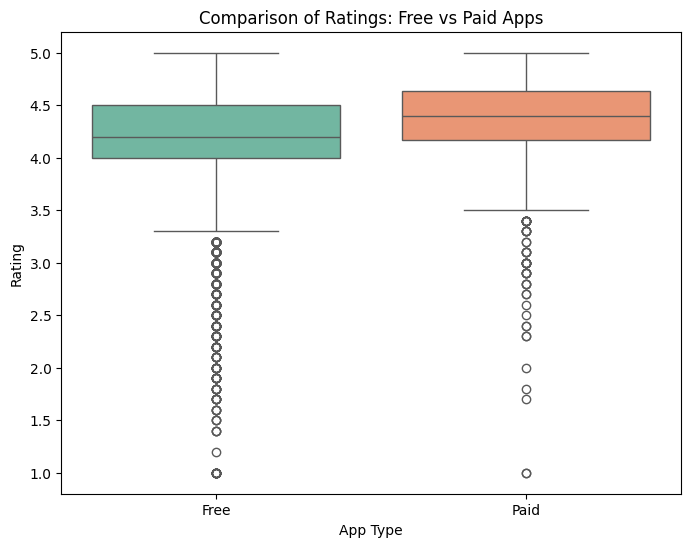

Type
Free    4.184893
Paid    4.296775
Name: Rating, dtype: float64

In [180]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Type', y='Rating', data=df, palette='Set2')
plt.title('Comparison of Ratings: Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Rating')
plt.show()

df.groupby('Type')['Rating'].mean()

#### **Observations**
- On average, paid apps have slightly higher and more consistent ratings compared to free apps.
- This is likely because paid users are more selective, and developers of paid apps tend to invest more in quality and user experience.
- In contrast, free apps often include ads or limited features, attracting a wider audience and resulting in more varied ratings.
- However, the difference in average rating is relatively small, indicating that many free apps also maintain strong user satisfaction.
---


### **3.7. Which Content Rating group dominates the Play Store?**

Content Rating
Everyone           7881
Teen               1034
Mature 17+          393
Everyone 10+        321
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

 Content Rating   Category          
Adults only 18+  COMICS                   2
                 SPORTS                   1
Everyone         FAMILY                1447
                 TOOLS                  819
                 GAME                   488
Everyone 10+     FAMILY                 117
                 GAME                   102
                 NEWS_AND_MAGAZINES      46
Mature 17+       DATING                 145
                 GAME                    65
                 FAMILY                  50
Teen             GAME                   291
                 FAMILY                 255
                 SOCIAL                 103
Unrated          FAMILY                   1
                 TOOLS                    1
Name: count, dtype: int64


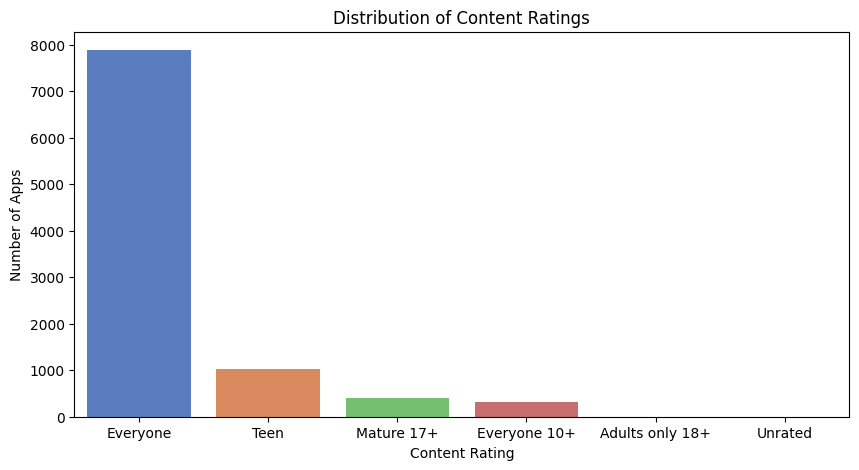

In [181]:
content_counts = df['Content Rating'].value_counts()
print(content_counts)

top_categories_by_rating = df.groupby('Content Rating')['Category'].value_counts().groupby(level=0).head(3)
print("\n",top_categories_by_rating)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=content_counts.index, y=content_counts.values, palette='muted')
plt.title('Distribution of Content Ratings')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.show()

#### **Observations**

- Most apps are rated “Everyone”, mainly from Family, Tools, and Game categories — showing the Play Store is largely family-friendly.
- “Teen” apps are mostly in Game and Social categories, reflecting higher interactivity or mild maturity.
- “Mature 17+” apps are concentrated in Dating and Game, indicating adult-oriented content.
- Very few apps are “Adults only 18+” or Unrated, likely due to Play Store policy restrictions.

> Summary: The Play Store is dominated by family-safe apps, with limited mature-content categories catering to specific audiences.
---

#### **3.8. Which genres have the most high-rated apps?**

In [182]:
top_genres = df.groupby('Genres')['Rating'].mean().sort_values(ascending=False).round(2)
top_genres.head(10)

Genres
Board;Pretend Play             4.80
Comics;Creativity              4.80
Health & Fitness;Education     4.70
Adventure;Brain Games          4.60
Puzzle;Education               4.60
Strategy;Action & Adventure    4.60
Entertainment;Creativity       4.53
Music;Music & Video            4.53
Strategy;Education             4.50
Racing;Pretend Play            4.50
Name: Rating, dtype: float64

#### **Observations**

- The genres “Board;Pretend Play” and “Comics;Creativity” top the list, each with an average rating of 4.8, indicating strong user satisfaction.

- Educational and creative sub-genres such as “Health & Fitness;Education”, “Puzzle;Education”, and “Strategy;Education” also perform exceptionally well, suggesting users value learning and interactive experiences.

- Action-related hybrids like “Adventure;Brain Games” and “Strategy;Action & Adventure” show that engaging gameplay combined with mental challenge tends to receive high ratings.

- Overall, genres that combine education, creativity, and fun appear to be the most appreciated by users.

---
#### **3.9. Relationship between App Size and Rating**

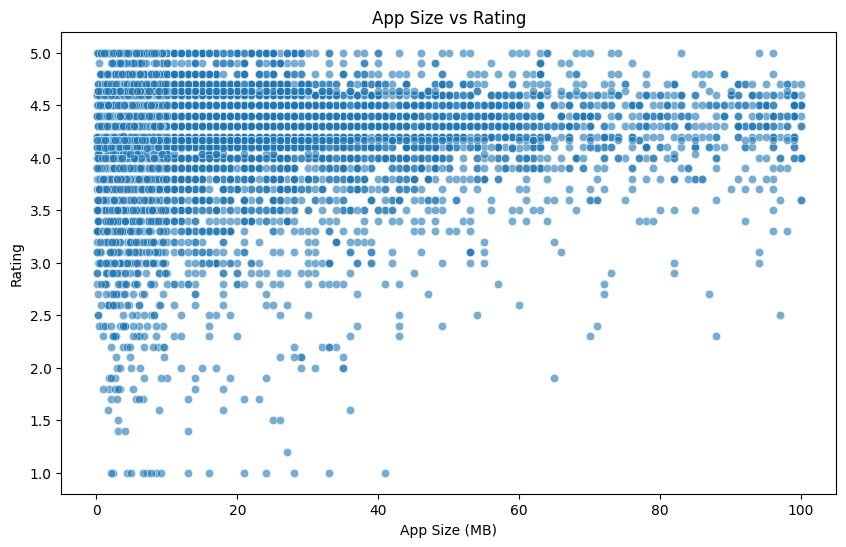

In [183]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Size_in_MB', y='Rating', data=df, alpha=0.6)
plt.title('App Size vs Rating')
plt.xlabel('App Size (MB)')
plt.ylabel('Rating')
plt.show()

#### **Observations**

- Most apps, regardless of their size, receive ratings between 4.0 and 4.5, suggesting that app quality isn’t strongly dependent on size.

- Smaller apps (below 20 MB) show a wide range of ratings, including several low-rated ones, indicating that lighter apps may vary more in quality or functionality.

- Larger apps (above 50 MB) tend to maintain consistently high ratings, possibly because they offer richer features, better graphics, or smoother performance.

- There’s no clear linear correlation between app size and rating — instead, ratings appear clustered near the top across all sizes.

- Overall, app quality (as reflected by rating) depends more on user experience and utility than on file size alone.
---

#### **3.10. Relationship between Installs and Price**

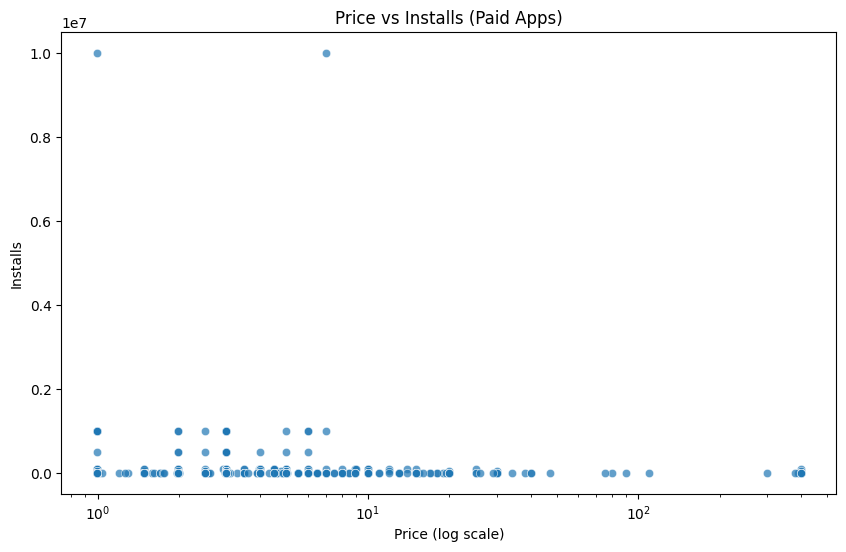

In [184]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Price', y='Installs', data=df[df['Price'] > 0], alpha=0.7)
plt.xscale('log')
plt.title('Price vs Installs (Paid Apps)')
plt.xlabel('Price (log scale)')
plt.ylabel('Installs')
plt.show()

#### **Observations**

- Most paid apps are priced at lower ranges, with only a few premium apps crossing the $50 mark.

- A clear inverse relationship is visible — as the price increases, the number of installs decreases sharply.

- This indicates that users are more inclined to download lower-priced apps, while higher-priced apps attract significantly fewer downloads.

- A few mid-range apps (priced between $5–$10) manage to achieve relatively higher installs, likely due to strong brand reputation or niche utility.

- Overall, the data suggests that pricing plays a crucial role in user adoption, with affordability driving higher install volumes.
---

## **Final Summary & Conclusion**

This project explored the Google Play Store dataset to understand app performance, user behavior, and key business insights.
Through detailed Exploratory Data Analysis (EDA), multiple patterns were uncovered that shed light on what drives app success in the market.

**Key Insights**

1. App Distribution

    - The Family and Game categories dominate the Play Store, indicating developers’ strong focus on entertainment and family-based content.
    - Niche categories like Beauty, Comics, and Parenting have fewer apps, showing potential opportunities for new entrants.

2. User Engagement & Popularity

    - Games and Communication apps have the highest total installs and reviews, revealing strong user engagement and loyalty.
    - Tools and Productivity apps maintain steady popularity due to their everyday utility.

3. Revenue Trends (Paid Apps)

    - The Family and Lifestyle categories contribute the most revenue, showing users’ willingness to pay for apps offering value and personalization.
    - Most paid apps are priced at lower ranges, confirming that affordable pricing drives higher downloads.
    - A few premium apps (> $50) exist but attract limited installs.

4. App Quality & Ratings

    - The majority of apps have ratings between 4.0 and 4.5, suggesting overall user satisfaction.
    - Categories like Events, Art & Design, and Books & Reference achieve the highest average ratings, indicating high-quality experiences in creative and informative domains.
    - Very few apps fall below 3.0, showing that poorly rated apps are rare or phased out.

5. App Size vs Rating

    - No strong relationship exists between app size and ratings — even small-sized apps can achieve excellent ratings.
    - This highlights that performance, usability, and experience matter more to users than app size.

---
### **Overall Conclusion**

- The Play Store ecosystem is user-driven, where apps combining affordability, reliability, and engaging experience perform best.

- Games, Family, and Lifestyle categories dominate both in reach and revenue.

- High-rated categories tend to focus on creativity, education, and personalization.

- Developers can target underrepresented niches while ensuring strong UI/UX and competitive pricing to maximize adoption.

---